# Task 1: Character-Level GPT on TinyStories (Parth)

DATA 266 Lab 1, Task 1.

## 1. Objective

I train a small decoder-only Transformer from scratch to predict the next character of children's stories (TinyStories). Self-attention, the causal mask, the positional embeddings and the residual and LayerNorm blocks are written by hand below; `torch.nn.Transformer`, `nn.MultiheadAttention` and pretrained models are not used.

The notebook covers the character tokenizer and my own train/validation split (sections 4 to 6), the model (7), training and evaluation (8 to 10, 12, 13), text generation (11, 13), failure analysis (14) and the architecture and hyperparameter discussion (15).

**Running it.** Select the project kernel and use *Restart & Run All*. The notebook trains the model, generates the samples, computes every metric and shows the results. It needs a TinyStories training file in `task1_llm/data/` and the packages in `requirements.txt`.

**Outputs.** Everything the notebook writes (config copy, checkpoints, processed data, logs, figures, samples, metrics report, raw log, manifest) goes to `task1_llm/parth/notebook_runs/<RUN_TAG>/`. Nothing outside that folder is changed.

The next cell holds the only settings meant to be edited.

In [1]:
import os

RUN_MODE = os.environ.get("TASK1_RUN_MODE", "full")  # "full": the reported experiment; "smoke": tiny model, 2 epochs, end-to-end check
RUN_TAG = os.environ.get("TASK1_RUN_TAG", "gpu_run")  # outputs go to task1_llm/parth/notebook_runs/<RUN_TAG>/
VERIFY_REPORTED_CHECKPOINT = os.environ.get("TASK1_VERIFY_REPORTED", "1") == "1"  # also re-evaluate the reported best.pt (section 13)
ALLOW_CPU_FULL_RUN = os.environ.get("TASK1_ALLOW_CPU", "0") == "1"  # the full run is meant for a CUDA GPU

assert RUN_MODE in ("full", "smoke"), RUN_MODE

## 2. Imports and reproducibility

Only the standard library, PyTorch, NumPy, pandas, PyYAML and matplotlib are needed. The repository root is found by walking up from the working directory, so the notebook runs the same from the repository root or from `src/`, and paths in logs, manifests and tables are relative to that root.

In [2]:
from __future__ import annotations

import argparse
import copy
import csv
import io
import json
import logging
import math
import platform
import random
import subprocess
import sys
import time
import warnings
from collections import Counter
from dataclasses import asdict, dataclass, fields
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from IPython.display import Image, Markdown, display
from torch.utils.data import DataLoader, Dataset, Subset

# Saved outputs must not show machine-specific paths, which the default warning format prints.
warnings.formatwarning = lambda message, category, *args, **kwargs: f"{category.__name__}: {message}\n"
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)

### Paths and configuration helpers

`REPO_ROOT` is the folder that contains `task1_llm/`. Every relative path in the config is resolved against it.

In [3]:
def find_repo_root(marker: str = "task1_llm/parth") -> Path:
    """The repository root is the closest folder above the working directory that contains task1_llm/parth."""
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / marker).is_dir():
            return base
    raise FileNotFoundError(f"{marker}/ not found above the working directory; start Jupyter inside the repository.")


REPO_ROOT = find_repo_root()


def resolve_path(path: str | Path) -> Path:
    """Return an absolute path; relative paths are interpreted from the repo root."""
    p = Path(path)
    return p if p.is_absolute() else REPO_ROOT / p


def repo_relative(path: str | Path) -> str:
    """Render a path relative to the repo root for logs, so no personal paths leak."""
    p = Path(path).resolve()
    try:
        return p.relative_to(REPO_ROOT).as_posix()
    except ValueError:
        return p.name


def load_yaml(path: str | Path) -> dict:
    with open(resolve_path(path), "r", encoding="utf-8") as f:
        return yaml.safe_load(f) or {}


def deep_merge(base: dict, override: dict) -> dict:
    """Recursively merge override into a copy of base and return the result."""
    out = copy.deepcopy(base)
    for key, value in (override or {}).items():
        if isinstance(value, dict) and isinstance(out.get(key), dict):
            out[key] = deep_merge(out[key], value)
        else:
            out[key] = copy.deepcopy(value)
    return out


def load_config(config_path: str | Path, smoke: bool = False) -> dict:
    """Load train.yaml, pull in the model.yaml it points to, and optionally apply the
    smoke-test overrides. The returned dict carries the architecture under "model".
    """
    cfg = load_yaml(config_path)
    model_path = cfg.get("model_config")
    model_cfg = load_yaml(model_path) if model_path else {}
    cfg["model"] = deep_merge(model_cfg, cfg.get("model", {}) or {})
    smoke_cfg = cfg.pop("smoke", {}) or {}
    if smoke:
        cfg = deep_merge(cfg, smoke_cfg)
    cfg["is_smoke"] = bool(smoke)
    return cfg

### Seeding, device, timestamps, environment capture, and file helpers

In [4]:
def set_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def utc_timestamp() -> str:
    return datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")


def utc_iso() -> str:
    return datetime.now(timezone.utc).isoformat(timespec="seconds")

In [5]:
def _run(cmd: list[str], timeout: int = 60) -> str | None:
    try:
        out = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout, cwd=REPO_ROOT)
        return out.stdout.strip() if out.returncode == 0 else None
    except (OSError, subprocess.SubprocessError):
        return None


def git_info() -> dict:
    status = _run(["git", "status", "--porcelain"])
    return {
        "commit": _run(["git", "rev-parse", "HEAD"]),
        "branch": _run(["git", "rev-parse", "--abbrev-ref", "HEAD"]),
        "dirty": None if status is None else bool(status),
    }


def pip_freeze() -> str:
    return _run([sys.executable, "-m", "pip", "freeze"], timeout=120) or "pip freeze unavailable"


def collect_environment() -> dict:
    env: dict[str, Any] = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "torch": torch.__version__,
        "torch_cuda_build": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version() if torch.backends.cudnn.is_available() else None,
        "numpy": np.__version__,
        "pyyaml": yaml.__version__,
        "cuda_available": torch.cuda.is_available(),
    }
    try:
        import matplotlib

        env["matplotlib"] = matplotlib.__version__
    except ImportError:
        env["matplotlib"] = None
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        env.update(
            {
                "gpu_name": props.name,
                "gpu_compute_capability": f"{props.major}.{props.minor}",
                "gpu_total_memory_gb": round(props.total_memory / 1024**3, 2),
                "gpu_count": torch.cuda.device_count(),
                "nvidia_driver": _run(
                    ["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"]
                ),
            }
        )
    else:
        env["cpu"] = platform.processor() or platform.machine()
    return env


def write_json(path: str | Path, obj: Any) -> Path:
    p = resolve_path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)
    return p


def read_json(path: str | Path) -> Any:
    with open(resolve_path(path), "r", encoding="utf-8") as f:
        return json.load(f)


def write_csv(path: str | Path, rows: list[dict], columns: list[str]) -> Path:
    p = resolve_path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=columns)
        writer.writeheader()
        for row in rows:
            writer.writerow({c: row.get(c, "") for c in columns})
    return p

In [6]:
def show_table(rows, **kwargs):
    display(pd.DataFrame(rows, **kwargs))


def show_fig(fig):
    """Render a matplotlib figure as a PNG (works with any matplotlib backend) and close it."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buf.getvalue()))


def cpu_model_name():
    try:
        if sys.platform.startswith("linux"):
            for line in Path("/proc/cpuinfo").read_text().splitlines():
                if line.lower().startswith("model name"):
                    return line.split(":", 1)[1].strip()
        elif sys.platform == "darwin":
            out = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True)
            if out.stdout.strip():
                return out.stdout.strip()
    except OSError:
        pass
    return platform.processor() or platform.machine()

### Seed and hardware

The run seed is 8503. `set_seed` seeds Python, NumPy, and PyTorch (CPU and CUDA); the training, generation, and evaluation functions call it again with the same seed before they start.

In [7]:
SEED = 8503
set_seed(SEED)
DEVICE = get_device()
ENV = collect_environment()

show_table([
    ("python", ENV["python"]),
    ("platform", ENV["platform"]),
    ("torch", ENV["torch"]),
    ("torch CUDA build", ENV["torch_cuda_build"]),
    ("GPU", ENV.get("gpu_name")),
    ("GPU compute capability", ENV.get("gpu_compute_capability")),
    ("GPU memory (GB)", ENV.get("gpu_total_memory_gb")),
    ("CPU", cpu_model_name()),
    ("CPU logical cores", os.cpu_count()),
    ("device used", str(DEVICE)),
    ("seed", SEED),
    ("run mode", RUN_MODE),
], columns=["item", "value"])

if RUN_MODE == "full" and DEVICE.type != "cuda" and not ALLOW_CPU_FULL_RUN:
    raise RuntimeError("RUN_MODE='full' trains the reported model and needs a CUDA GPU. Run on the GPU machine, "
                       "set RUN_MODE='smoke' for a small CPU check, or set TASK1_ALLOW_CPU=1 to force CPU.")

,item,value
0,python,3.12.10
1,platform,Windows-11-10.0.26200-SP0
2,torch,2.14.1+cu130
3,torch CUDA build,13.0
4,GPU,NVIDIA GeForce RTX 5090
5,GPU compute capability,12.0
6,GPU memory (GB),31.84
7,CPU,"Intel64 Family 6 Model 198 Stepping 2, GenuineIntel"
8,CPU logical cores,24
9,device used,cuda


## 3. Configuration

All hyperparameters of the experiment are in the two dictionaries below: `MODEL_CONFIG` (architecture) and `TRAIN_CONFIG` (data, training, output paths). The `smoke` block holds the overrides of the small end-to-end check (`RUN_MODE = "smoke"`); it is not used by the full run.

The values are the ones of the reported run `parth_gpt_char_v1_20260925T214701Z`. The cell after the dictionaries asserts that they are identical to `config/train.yaml`, `config/model.yaml`, and to the config recorded in the reported run's manifest, whenever those files are present. Only the output paths differ: they point into this notebook's run folder.

In [8]:
MEMBER_DIR = REPO_ROOT / "task1_llm" / "parth"
RUN_DIR = MEMBER_DIR / "notebook_runs" / RUN_TAG
RUN_REL = repo_relative(RUN_DIR)

MODEL_CONFIG = {
    "model_type": "decoder-only-gpt",
    "tokenization": "character-level",
    "normalization": "pre-norm",
    "positional_embedding": "learned",
    "activation": "gelu",
    "d_model": 256,
    "n_heads": 8,
    "n_layers": 4,
    "context_length": 128,
    "dropout": 0.1,
    "ffn_hidden_multiplier": 4,
    "bias": True,
    "tie_weights": False,
}

TRAIN_CONFIG = {
    "run_name": "parth_gpt_char_v1",
    "seed": SEED,
    "model_config": f"{RUN_REL}/config/model.yaml",
    "data": {
        "data_dir": "task1_llm/data",
        "data_file": None,
        "max_stories_to_load": 80000,
        "story_separator": "\n\n",
        "split_unit": "sequences",
        "train_size": 100000,
        "val_size": 10000,
        "window_stride": None,
        "min_char_freq": 1,
        "processed_dir": f"{RUN_REL}/data_processed",
        "tokenizer_path": f"{RUN_REL}/data_processed/tokenizer.json",
    },
    "training": {
        "epochs": 10,
        "batch_size": 128,
        "learning_rate": 0.0003,
        "min_lr_ratio": 0.1,
        "weight_decay": 0.01,
        "betas": [0.9, 0.95],
        "warmup_ratio": 0.05,
        "warmup_steps": None,
        "grad_clip": 1.0,
        "amp": True,
        "amp_dtype": "auto",
        "allow_tf32": True,
        "num_workers": 2,
        "log_interval": 50,
        "spike_factor": 2.0,
        "eval_train_batches": 100,
    },
    "paths": {
        "checkpoint_dir": f"{RUN_REL}/checkpoints",
        "figures_dir": f"{RUN_REL}/figures",
        "logs_dir": f"{RUN_REL}/logs",
        "outputs_dir": f"{RUN_REL}/outputs",
        "metrics_report": f"{RUN_REL}/metrics_report.csv",
        "raw_log_dir": f"{RUN_REL}/raw_logs",
        "manifest_dir": f"{RUN_REL}/manifests",
    },
    "smoke": {
        "run_name": "parth_gpt_char_v1",
        "model": {"d_model": 64, "n_heads": 4, "n_layers": 2, "context_length": 64},
        "data": {
            "max_stories_to_load": 3000,
            "train_size": 2000,
            "val_size": 200,
            "processed_dir": f"{RUN_REL}/smoke/data_processed",
            "tokenizer_path": f"{RUN_REL}/smoke/data_processed/tokenizer.json",
        },
        "training": {"epochs": 2, "batch_size": 32, "num_workers": 0, "log_interval": 10, "eval_train_batches": 5},
        "paths": {
            "checkpoint_dir": f"{RUN_REL}/smoke/checkpoints",
            "figures_dir": f"{RUN_REL}/smoke/figures",
            "logs_dir": f"{RUN_REL}/smoke/logs",
            "outputs_dir": f"{RUN_REL}/smoke/outputs",
            "metrics_report": f"{RUN_REL}/smoke/metrics_report.csv",
        },
    },
}

In [9]:
REPORTED_RUN_ID = "parth_gpt_char_v1_20260925T214701Z"


def strip_paths(train_cfg):
    """Config without the keys that only say where files are written."""
    c = copy.deepcopy(train_cfg)
    c.pop("model_config", None)
    for section in (c, c.get("smoke", {})):
        section.pop("paths", None)
        for key in ("processed_dir", "tokenizer_path"):
            section.get("data", {}).pop(key, None)
    return c


consistency = []
yaml_train, yaml_model = MEMBER_DIR / "config" / "train.yaml", MEMBER_DIR / "config" / "model.yaml"
if yaml_train.exists():
    consistency.append(("config/train.yaml", strip_paths(load_yaml(yaml_train)) == strip_paths(TRAIN_CONFIG)))
if yaml_model.exists():
    consistency.append(("config/model.yaml", load_yaml(yaml_model) == MODEL_CONFIG))
reported_manifest = REPO_ROOT / "reproducibility" / "manifests" / f"task1_parth_{REPORTED_RUN_ID}.json"
if reported_manifest.exists():
    recorded = read_json(reported_manifest)["config"]
    recorded_model = recorded.pop("model")
    recorded.pop("is_smoke")
    full_only = {k: v for k, v in TRAIN_CONFIG.items() if k != "smoke"}
    consistency.append(("manifest of the reported run: data / training", strip_paths(recorded) == strip_paths(full_only)))
    consistency.append(("manifest of the reported run: model", recorded_model == MODEL_CONFIG))
show_table(consistency, columns=["reference", "identical (output paths excluded)"])
assert all(ok for _, ok in consistency), "the notebook config differs from the reported configuration"

,reference,identical (output paths excluded)
0,config/train.yaml,True
1,config/model.yaml,True
2,manifest of the reported run: data / training,True
3,manifest of the reported run: model,True


The two dictionaries are written to `notebook_runs/<RUN_TAG>/config/` and read back with `load_config`, which merges the model config into `cfg["model"]` (and applies the `smoke` block in smoke mode). `cfg` is exactly what the training function receives.

In [10]:
CONFIG_DIR = RUN_DIR / "config"
CONFIG_DIR.mkdir(parents=True, exist_ok=True)
(CONFIG_DIR / "model.yaml").write_text(yaml.safe_dump(MODEL_CONFIG, sort_keys=False), encoding="utf-8")
(CONFIG_DIR / "train.yaml").write_text(yaml.safe_dump(TRAIN_CONFIG, sort_keys=False), encoding="utf-8")
CONFIG_PATH = f"{RUN_REL}/config/train.yaml"

SMOKE = RUN_MODE == "smoke"
cfg = load_config(CONFIG_PATH, smoke=SMOKE)


def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        key = f"{prefix}{k}"
        if isinstance(v, dict):
            out.update(flatten(v, key + "."))
        else:
            out[key] = v
    return out


print("run folder:", RUN_REL, "| smoke overrides applied:", cfg["is_smoke"])
for section in ("model", "data", "training"):
    show_table([(k, repr(v)) for k, v in flatten(cfg[section]).items()], columns=[f"cfg['{section}']", "value"])

run folder: task1_llm/parth/notebook_runs/gpu_run | smoke overrides applied: False


,cfg['model'],value
0,model_type,'decoder-only-gpt'
1,tokenization,'character-level'
2,normalization,'pre-norm'
3,positional_embedding,'learned'
4,activation,'gelu'
5,d_model,256
6,n_heads,8
7,n_layers,4
8,context_length,128
9,dropout,0.1


,cfg['data'],value
0,data_dir,'task1_llm/data'
1,data_file,None
2,max_stories_to_load,80000
3,story_separator,'\n\n'
4,split_unit,'sequences'
5,train_size,100000
6,val_size,10000
7,window_stride,None
8,min_char_freq,1
9,processed_dir,'task1_llm/parth/notebook_runs/gpu_run/data_processed'


,cfg['training'],value
0,epochs,10
1,batch_size,128
2,learning_rate,0.0003
3,min_lr_ratio,0.1
4,weight_decay,0.01
5,betas,"[0.9, 0.95]"
6,warmup_ratio,0.05
7,warmup_steps,None
8,grad_clip,1.0
9,amp,True


## 4. Dataset: loading and splitting

TinyStories is read from `task1_llm/data/` (`.txt` with `<|endoftext|>` delimiters, `.jsonl`, or `.json`). The split is made on whole stories before any window is cut, so no story contributes characters to both splits:

1. Read the first `max_stories_to_load` stories (80,000) and shuffle them with the run seed (8503).
2. Assign whole stories to validation until there is enough text for `val_size` windows, then assign the following stories to training until there is enough for `train_size` windows.
3. Join each split's stories into one text stream, fit the tokenizer on the training stream only (section 5), and cut each stream into fixed-length windows of `context_length` characters (section 6).

`split_unit` only sets what `train_size` and `val_size` count. With `split_unit = "sequences"` (the reported run) they count windows: 100,000 training and 10,000 validation windows of 128 characters. The `"stories"` and `"characters"` units are also implemented, and every unit assigns whole stories to one split; section 15 explains the choice.

In [11]:
STORY_DELIMITER = "<|endoftext|>"


TEXT_FIELDS = ("text", "story", "content")


SUPPORTED_SUFFIXES = (".txt", ".jsonl", ".json")


# 100K/10K is read as fixed-length sequences by default. "stories" and "characters" are
# also implemented, so the unit can be switched in train.yaml without code changes.
SUPPORTED_SPLIT_UNITS = ("sequences", "stories", "characters")


def find_data_file(data_dir: str | Path, data_file: str | None = None) -> Path:
    """Return the TinyStories file to use, preferring a file whose name contains 'train'."""
    if data_file:
        path = resolve_path(data_file)
        if not path.exists():
            raise FileNotFoundError(f"data_file not found: {repo_relative(path)}")
        return path
    directory = resolve_path(data_dir)
    if not directory.exists():
        raise FileNotFoundError(f"data_dir not found: {repo_relative(directory)}")
    candidates = sorted(p for p in directory.iterdir() if p.is_file() and p.suffix in SUPPORTED_SUFFIXES)
    if not candidates:
        raise FileNotFoundError(
            f"No .txt/.jsonl/.json file in {repo_relative(directory)}. "
            "Download TinyStories first (see task1_llm/data/README.md)."
        )
    train_like = [p for p in candidates if "train" in p.name.lower() and "valid" not in p.name.lower()]
    return (train_like or candidates)[0]


def _iter_txt_stories(path: Path) -> Iterator[str]:
    """Stream stories from a .txt file without reading the whole file into memory."""
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        head = f.read(1 << 20)
        f.seek(0)
        use_delimiter = STORY_DELIMITER in head
        buffer: list[str] = []
        for line in f:
            if use_delimiter:
                if STORY_DELIMITER in line:
                    parts = line.split(STORY_DELIMITER)
                    buffer.append(parts[0])
                    yield "".join(buffer)
                    yield from parts[1:-1]
                    buffer = [parts[-1]]
                else:
                    buffer.append(line)
            elif line.strip() == "":
                # Why: without an explicit delimiter, a blank line is the story boundary.
                if buffer:
                    yield "".join(buffer)
                    buffer = []
            else:
                buffer.append(line)
        if buffer:
            yield "".join(buffer)


def _extract_text(record) -> str | None:
    if isinstance(record, str):
        return record
    if isinstance(record, dict):
        for key in TEXT_FIELDS:
            value = record.get(key)
            if isinstance(value, str):
                return value
    return None


def _iter_jsonl_stories(path: Path) -> Iterator[str]:
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                text = _extract_text(json.loads(line))
            except json.JSONDecodeError:
                continue
            if text is not None:
                yield text


def _iter_json_stories(path: Path) -> Iterator[str]:
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        data = json.load(f)
    if isinstance(data, dict):
        list_values = [v for v in data.values() if isinstance(v, list)]
        records = list_values[0] if list_values else [data]
    elif isinstance(data, list):
        records = data
    else:
        records = []
    for record in records:
        text = _extract_text(record)
        if text is not None:
            yield text


def iter_stories(path: str | Path) -> Iterator[str]:
    path = Path(path)
    if path.suffix == ".txt":
        return _iter_txt_stories(path)
    if path.suffix == ".jsonl":
        return _iter_jsonl_stories(path)
    if path.suffix == ".json":
        return _iter_json_stories(path)
    raise ValueError(f"Unsupported data file type: {path.suffix}")


def load_stories(path: str | Path, max_stories: int | None = None) -> list[str]:
    """Load up to max_stories non-empty, whitespace-stripped stories in file order."""
    stories: list[str] = []
    for story in iter_stories(path):
        story = story.strip()
        if story:
            stories.append(story)
            if max_stories and len(stories) >= max_stories:
                break
    return stories

In [12]:
def chars_needed_for_windows(num_windows: int, context_length: int, stride: int) -> int:
    """Characters required to cut num_windows (x, y) pairs, where y is x shifted by one."""
    return (num_windows - 1) * stride + context_length + 1


def _take_until(stories: list[str], start: int, need_chars: int, separator: str):
    taken: list[str] = []
    total = 0
    i = start
    while total < need_chars:
        if i >= len(stories):
            raise ValueError(
                f"Ran out of stories: needed {need_chars:,} characters but the loaded pool is "
                "too small. Increase data.max_stories_to_load in train.yaml."
            )
        total += len(stories[i]) + (len(separator) if taken else 0)
        taken.append(stories[i])
        i += 1
    return taken, i


def split_stories(
    stories: list[str],
    split_unit: str,
    train_size: int,
    val_size: int,
    context_length: int,
    stride: int,
    separator: str,
    seed: int,
) -> tuple[list[str], list[str]]:
    """Shuffle stories with the seed, then assign whole stories to val first, then train."""
    if split_unit not in SUPPORTED_SPLIT_UNITS:
        raise ValueError(f"split_unit must be one of {SUPPORTED_SPLIT_UNITS}, got {split_unit!r}")
    shuffled = list(stories)
    random.Random(seed).shuffle(shuffled)

    if split_unit == "stories":
        if len(shuffled) < train_size + val_size:
            raise ValueError(
                f"Need {train_size + val_size:,} stories but only {len(shuffled):,} were loaded. "
                "Increase data.max_stories_to_load."
            )
        return shuffled[val_size : val_size + train_size], shuffled[:val_size]

    if split_unit == "characters":
        val_need, train_need = val_size, train_size
    else:
        val_need = chars_needed_for_windows(val_size, context_length, stride)
        train_need = chars_needed_for_windows(train_size, context_length, stride)

    # Why: splitting whole stories, never mid-story, means no validation story shares a
    # single character window with the training stream.
    val, pos = _take_until(shuffled, 0, val_need, separator)
    train, _ = _take_until(shuffled, pos, train_need, separator)
    return train, val

In [13]:
DATA_FILE = find_data_file(cfg["data"]["data_dir"], cfg["data"].get("data_file"))
print("data file:", repo_relative(DATA_FILE))
for i, story in enumerate(load_stories(DATA_FILE, 2), 1):
    print(f"--- story {i} ({len(story)} characters) ---")
    print(story[:400] + (" ..." if len(story) > 400 else ""))

data file: task1_llm/data/TinyStoriesV2-GPT4-train.txt
--- story 1 (730 characters) ---
Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, “Wow, that is a really amazing vase! Can I buy it?” 
The shopkeeper smiled and said, “Of course yo ...
--- story 2 (661 characters) ---
Once upon a time, there was a reliable otter named Ollie. He lived in a river with his family. They all loved to play and swim together.
One day, Ollie's mom said, "Ollie, hurry and get some fish for dinner!" Ollie swam fast to catch fish. He saw his friend, the duck. "Hi, Ollie!" said the duck. "Hi, duck!" said Ollie. "I need to hurry and catch fish for my family."
While Ollie was catching fish,  ...


## 5. Character tokenizer

`CharTokenizer` maps every distinct training character to an integer id. Id 0 is reserved for an unknown-character token (U+FFFD), used for validation or prompt characters that never occur in the training text. `char_to_idx` and `idx_to_char` are the two lookup tables; `encode` and `decode` convert between text and ids. The vocabulary is fitted on the training split only (section 6).

In [14]:
# Why: U+FFFD is the standard Unicode replacement character, so an unknown id decodes to
# a visible marker instead of silently vanishing from generated text.
UNK_CHAR = "\ufffd"


class CharTokenizer:
    """Maps single characters to integer ids with its own char_to_idx / idx_to_char."""

    def __init__(self, min_freq: int = 1):
        if min_freq < 1:
            raise ValueError("min_freq must be >= 1")
        self.min_freq = min_freq
        self.char_to_idx: dict[str, int] = {}
        self.idx_to_char: dict[int, str] = {}
        self.unk_idx = 0
        self.num_rare_chars_dropped = 0

    # ------------------------------------------------------------------ building
    def fit(self, text: str) -> "CharTokenizer":
        """Build the vocabulary from training text. Never call this on validation text."""
        if not text:
            raise ValueError("Cannot fit a tokenizer on empty text")
        counts = Counter(text)
        counts.pop(UNK_CHAR, None)
        kept = sorted(c for c, n in counts.items() if n >= self.min_freq)
        self.num_rare_chars_dropped = len(counts) - len(kept)
        # Why: id 0 is reserved for unknown characters so validation text containing a
        # character absent from the training split still encodes cleanly.
        self._set_vocab([UNK_CHAR] + kept)
        return self

    def _set_vocab(self, vocab: list[str]) -> None:
        if not vocab or vocab[0] != UNK_CHAR:
            raise ValueError("Vocabulary must start with the unknown character")
        if len(set(vocab)) != len(vocab):
            raise ValueError("Vocabulary contains duplicate characters")
        self.char_to_idx = {ch: i for i, ch in enumerate(vocab)}
        self.idx_to_char = {i: ch for i, ch in enumerate(vocab)}
        self.unk_idx = 0

    @property
    def vocab_size(self) -> int:
        return len(self.char_to_idx)

    @property
    def vocab(self) -> list[str]:
        return [self.idx_to_char[i] for i in range(self.vocab_size)]

    def _check_fitted(self) -> None:
        if not self.char_to_idx:
            raise RuntimeError("Tokenizer is not fitted; call fit() or load() first")

    # ------------------------------------------------------------------ encode / decode
    def encode(self, text: str) -> list[int]:
        self._check_fitted()
        lookup = self.char_to_idx
        unk = self.unk_idx
        return [lookup.get(ch, unk) for ch in text]

    def decode(self, ids) -> str:
        self._check_fitted()
        table = self.idx_to_char
        return "".join(table.get(int(i), UNK_CHAR) for i in ids)

    def count_unknown(self, text: str) -> int:
        """Number of characters in text that would map to the unknown id."""
        self._check_fitted()
        return sum(1 for ch in text if ch not in self.char_to_idx)

    # ------------------------------------------------------------------ persistence
    def to_dict(self) -> dict:
        self._check_fitted()
        return {
            "type": "char",
            "unk_char": UNK_CHAR,
            "unk_idx": self.unk_idx,
            "min_freq": self.min_freq,
            "vocab_size": self.vocab_size,
            "vocab": self.vocab,
        }

    @classmethod
    def from_dict(cls, data: dict) -> "CharTokenizer":
        if data.get("type") != "char":
            raise ValueError(f"Not a character tokenizer: type={data.get('type')}")
        tok = cls(min_freq=int(data.get("min_freq", 1)))
        tok._set_vocab(list(data["vocab"]))
        return tok

    def save(self, path: str | Path) -> Path:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.to_dict(), f, ensure_ascii=False, indent=2)
        return path

    @classmethod
    def load(cls, path: str | Path) -> "CharTokenizer":
        with open(path, "r", encoding="utf-8") as f:
            return cls.from_dict(json.load(f))

    def __repr__(self) -> str:
        return f"CharTokenizer(vocab_size={self.vocab_size}, min_freq={self.min_freq})"

In [15]:
demo_text = "Once upon a time, there was a little girl named Lily. She liked to play outside."
demo_tok = CharTokenizer().fit(demo_text)
print(demo_tok)
print("idx_to_char:", {i: demo_tok.idx_to_char[i] for i in range(8)}, "...")
print("char_to_idx:", {c: demo_tok.char_to_idx[c] for c in "Once"})
demo_ids = demo_tok.encode("Once upon a time")
print("encode('Once upon a time') ->", demo_ids)
print("decode(...)                ->", repr(demo_tok.decode(demo_ids)))
print("unknown characters in 'Zebra!':", demo_tok.count_unknown("Zebra!"), "->", repr(demo_tok.decode(demo_tok.encode("Zebra!"))))

CharTokenizer(vocab_size=26, min_freq=1)
idx_to_char: {0: '�', 1: ' ', 2: ',', 3: '.', 4: 'L', 5: 'O', 6: 'S', 7: 'a'} ...
char_to_idx: {'O': 5, 'n': 17, 'c': 8, 'e': 10}
encode('Once upon a time') -> [5, 17, 8, 10, 1, 23, 19, 18, 17, 1, 7, 1, 22, 13, 16, 10]
decode(...)                -> 'Once upon a time'
unknown characters in 'Zebra!': 3 -> '�e�ra�'


## 6. Sequence dataset

The encoded text of each split is one long id tensor. `CharWindowDataset` cuts it into windows: for a window starting at position `i`, the input is `ids[i : i+T]` and the target is `ids[i+1 : i+T+1]`, so every position learns to predict the next character. `build_datasets` runs the whole pipeline (load, split, fit the tokenizer on the training text, encode, window) and returns the datasets with a metadata dictionary that the training summary records.

In [16]:
class CharWindowDataset(Dataset):
    """Fixed-length autoregressive windows over a 1-D id stream.

    Window i starts at i * stride. x has shape (T,) and y has shape (T,), with y equal
    to x shifted left by one character, so y[t] is the target for the prefix x[:t+1].
    """

    def __init__(self, ids: torch.Tensor, context_length: int, stride: int | None = None,
                 max_windows: int | None = None):
        if ids.dim() != 1:
            raise ValueError("ids must be a 1-D tensor")
        self.ids = ids
        self.context_length = int(context_length)
        self.stride = int(stride or context_length)
        if len(ids) < self.context_length + 1:
            raise ValueError(
                f"Need at least {self.context_length + 1} tokens, got {len(ids)}"
            )
        n = (len(ids) - self.context_length - 1) // self.stride + 1
        self.num_windows = min(n, max_windows) if max_windows else n

    def __len__(self) -> int:
        return self.num_windows

    def __getitem__(self, i: int):
        if i < 0 or i >= self.num_windows:
            raise IndexError(i)
        start = i * self.stride
        chunk = self.ids[start : start + self.context_length + 1].long()  # (T + 1,)
        x = chunk[:-1]  # (T,)
        y = chunk[1:]  # (T,)
        return x, y


def encode_to_tensor(tokenizer: CharTokenizer, text: str) -> torch.Tensor:
    # Why: int32 halves memory versus int64 for the full stream; windows are cast to
    # long only when a batch is sliced out.
    return torch.tensor(tokenizer.encode(text), dtype=torch.int32)


def make_dataloader(dataset: Dataset, batch_size: int, shuffle: bool, seed: int,
                    num_workers: int = 0, pin_memory: bool = False,
                    drop_last: bool = False) -> DataLoader:
    # Why: Windows spawns DataLoader workers, which can't load classes defined in this notebook's __main__.
    if sys.platform == "win32":
        num_workers = 0
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=pin_memory,
        generator=generator,
        persistent_workers=num_workers > 0,
    )

In [17]:
def build_datasets(data_cfg: dict, context_length: int, seed: int,
                   tokenizer: CharTokenizer | None = None) -> dict:
    """Load, split, tokenize, and window TinyStories in a leakage-safe order.

    Order: load stories, shuffle and split by story, fit the tokenizer on training text
    only (skipped when a tokenizer is passed in, e.g. for evaluation), encode both splits,
    then cut fixed-length windows. Returns datasets, id tensors, tokenizer, and split metadata.
    """
    path = find_data_file(data_cfg.get("data_dir", "task1_llm/data"), data_cfg.get("data_file"))
    split_unit = data_cfg.get("split_unit", "sequences")
    train_size = int(data_cfg["train_size"])
    val_size = int(data_cfg["val_size"])
    stride = int(data_cfg.get("window_stride") or context_length)
    separator = data_cfg.get("story_separator", "\n\n")
    max_stories = data_cfg.get("max_stories_to_load")

    stories = load_stories(path, max_stories)
    train_stories, val_stories = split_stories(
        stories, split_unit, train_size, val_size, context_length, stride, separator, seed
    )
    train_text = separator.join(train_stories)
    val_text = separator.join(val_stories)
    if split_unit == "characters":
        train_text, val_text = train_text[:train_size], val_text[:val_size]

    fitted_here = tokenizer is None
    if fitted_here:
        tokenizer = CharTokenizer(min_freq=int(data_cfg.get("min_char_freq", 1))).fit(train_text)

    train_ids = encode_to_tensor(tokenizer, train_text)
    val_ids = encode_to_tensor(tokenizer, val_text)
    cap_train = train_size if split_unit == "sequences" else None
    cap_val = val_size if split_unit == "sequences" else None
    train_ds = CharWindowDataset(train_ids, context_length, stride, cap_train)
    val_ds = CharWindowDataset(val_ids, context_length, stride, cap_val)

    meta = {
        "data_file": repo_relative(path),
        "split_unit": split_unit,
        "split_unit_note": "NEEDS_CLARIFICATION: confirm unit of the 100K/10K split",
        "train_size_requested": train_size,
        "val_size_requested": val_size,
        "seed": seed,
        "stories_loaded": len(stories),
        "stories_loaded_note": "first max_stories_to_load stories in file order, then seeded shuffle",
        "train_stories": len(train_stories),
        "val_stories": len(val_stories),
        "train_chars": len(train_text),
        "val_chars": len(val_text),
        "context_length": context_length,
        "window_stride": stride,
        "train_windows": len(train_ds),
        "val_windows": len(val_ds),
        "vocab_size": tokenizer.vocab_size,
        "tokenizer_fitted_on": "train split only" if fitted_here else "loaded from checkpoint",
        "val_unknown_chars": tokenizer.count_unknown(val_text),
        "story_separator": separator,
    }
    return {
        "tokenizer": tokenizer,
        "train_ds": train_ds,
        "val_ds": val_ds,
        "train_ids": train_ids,
        "val_ids": val_ids,
        "meta": meta,
    }


def save_processed(processed_dir: str | Path, train_ids: torch.Tensor, val_ids: torch.Tensor,
                   meta: dict) -> None:
    out = resolve_path(processed_dir)
    out.mkdir(parents=True, exist_ok=True)
    torch.save(train_ids, out / "train_ids.pt")
    torch.save(val_ids, out / "val_ids.pt")
    write_json(out / "split_meta.json", meta)


def load_processed(processed_dir: str | Path):
    """Return (train_ids, val_ids, meta) if a processed split exists, else None."""
    out = resolve_path(processed_dir)
    files = [out / "train_ids.pt", out / "val_ids.pt", out / "split_meta.json"]
    if not all(f.exists() for f in files):
        return None
    return torch.load(files[0]), torch.load(files[1]), read_json(files[2])

In [18]:
demo_T = 16  # shorter than the real context length so the table fits on screen
demo_ds = CharWindowDataset(encode_to_tensor(demo_tok, demo_text), context_length=demo_T)
x, y = demo_ds[0]
show_table({
    "input char": [demo_tok.idx_to_char[int(i)] for i in x],
    "input id": x.tolist(),
    "target char": [demo_tok.idx_to_char[int(i)] for i in y],
    "target id": y.tolist(),
})
print(f"{len(demo_ds)} windows of {demo_T} characters from a {len(demo_text)}-character text, stride {demo_ds.stride}. "
      f"The experiment uses T = {cfg['model']['context_length']}.")

,input char,input id,target char,target id
0,O,5,n,17
1,n,17,c,8
2,c,8,e,10
3,e,10,,1
4,,1,u,23
5,u,23,p,19
6,p,19,o,18
7,o,18,n,17
8,n,17,,1
9,,1,a,7


4 windows of 16 characters from a 80-character text, stride 16. The experiment uses T = 128.


## 7. Transformer implementation

A pre-norm, decoder-only Transformer. For an input of `T` character ids:

1. Token embedding plus learned positional embedding, then dropout.
2. `n_layers` Transformer blocks, each computing `x = x + Attention(LayerNorm(x))` and then `x = x + FFN(LayerNorm(x))`.
3. A final LayerNorm and a linear output projection to one logit per vocabulary character.

| Component | Implementation |
|---|---|
| Token embedding | `GPTLanguageModel.token_embedding` |
| Positional embedding | `GPTLanguageModel.position_embedding` (learned) |
| Multi-head self-attention | `MultiHeadSelfAttention` with `scaled_dot_product_attention` |
| Causal masking | `causal_mask` buffer (`torch.tril`); future scores are set to `-inf` before the softmax |
| Layer normalization | `TransformerBlock.ln1`, `TransformerBlock.ln2`, `GPTLanguageModel.ln_f` |
| Feed-forward network | `FeedForward` (Linear, GELU, Linear, dropout) |
| Residual connections | `TransformerBlock.forward` |
| Output projection | `GPTLanguageModel.lm_head` |

In [19]:
# Descriptive keys in model.yaml must match what this file actually implements, so the
# config can never claim an architecture the code does not build.
_IMPLEMENTED = {
    "model_type": "decoder-only-gpt",
    "tokenization": "character-level",
    "normalization": "pre-norm",
    "positional_embedding": "learned",
    "activation": "gelu",
}


def _normalize(value) -> str:
    return str(value).strip().lower().replace("_", "-").replace(" ", "-")


@dataclass
class GPTConfig:
    vocab_size: int
    context_length: int = 128
    d_model: int = 256
    n_heads: int = 8
    n_layers: int = 4
    dropout: float = 0.1
    ffn_hidden_multiplier: int = 4
    bias: bool = True
    tie_weights: bool = False

    def __post_init__(self):
        if self.d_model % self.n_heads != 0:
            raise ValueError(f"d_model={self.d_model} must be divisible by n_heads={self.n_heads}")
        if self.vocab_size < 2:
            raise ValueError("vocab_size must be >= 2")

    @property
    def head_dim(self) -> int:
        return self.d_model // self.n_heads

    @classmethod
    def from_dict(cls, cfg: dict, vocab_size: int | None = None) -> "GPTConfig":
        for key, expected in _IMPLEMENTED.items():
            if key in cfg and _normalize(cfg[key]) != expected:
                raise ValueError(f"model.yaml {key}={cfg[key]!r} but model.py implements {expected!r}")
        known = {f.name for f in fields(cls)}
        kwargs = {k: v for k, v in cfg.items() if k in known}
        if vocab_size is not None:
            kwargs["vocab_size"] = vocab_size
        return cls(**kwargs)

    def to_dict(self) -> dict:
        return asdict(self)

In [20]:
def scaled_dot_product_attention(q, k, v, mask=None, dropout_p: float = 0.0, training: bool = False):
    """Manual attention: softmax(Q K^T / sqrt(D)) V with an optional boolean mask.

    q, k, v have shape (B, H, T, D). mask is boolean and broadcastable to (B, H, T, T),
    with True meaning "query may attend to this key". Returns the per-head output of
    shape (B, H, T, D) and the pre-dropout attention weights of shape (B, H, T, T).
    """
    d = q.size(-1)
    # (B, H, T, D) @ (B, H, D, T) -> scores (B, H, T, T); row t = query t, column s = key s
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d)
    if mask is not None:
        # Blocked positions get -inf, so exp(-inf) = 0 after softmax: zero weight on the future.
        scores = scores.masked_fill(~mask, float("-inf"))
    # Why: softmax runs in float32 even under fp16/bf16 autocast, because exponentiating
    # low-precision logits is where attention overflow and NaNs usually start.
    weights = torch.softmax(scores.float(), dim=-1).to(q.dtype)  # (B, H, T, T), rows sum to 1
    attn = F.dropout(weights, p=dropout_p, training=training) if dropout_p > 0 else weights
    # (B, H, T, T) @ (B, H, T, D) -> (B, H, T, D): each query's weighted mix of value vectors
    out = torch.matmul(attn, v)
    return out, weights


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.n_heads = cfg.n_heads
        self.head_dim = cfg.head_dim
        self.d_model = cfg.d_model
        self.attn_dropout_p = cfg.dropout
        # Why: one fused (C -> 3C) projection is mathematically identical to three separate
        # Q, K, V layers but runs as a single matmul.
        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=cfg.bias)
        self.out_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=cfg.bias)
        self.resid_dropout = nn.Dropout(cfg.dropout)
        # Lower-triangular causal mask, (1, 1, T_max, T_max). Entry [t, s] is True when s <= t.
        mask = torch.tril(torch.ones(cfg.context_length, cfg.context_length, dtype=torch.bool))
        self.register_buffer("causal_mask", mask.view(1, 1, cfg.context_length, cfg.context_length),
                             persistent=False)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, C = x.shape  # x: (B, T, C)
        H, D = self.n_heads, self.head_dim

        q, k, v = self.qkv(x).split(C, dim=-1)  # (B, T, 3C) -> three tensors of (B, T, C)

        # Head split: (B, T, C) -> (B, T, H, D) -> (B, H, T, D) so each head attends independently
        q = q.view(B, T, H, D).transpose(1, 2)
        k = k.view(B, T, H, D).transpose(1, 2)
        v = v.view(B, T, H, D).transpose(1, 2)

        mask = self.causal_mask[:, :, :T, :T]  # (1, 1, T, T), broadcast over B and H
        out, weights = scaled_dot_product_attention(
            q, k, v, mask=mask, dropout_p=self.attn_dropout_p, training=self.training
        )  # out: (B, H, T, D), weights: (B, H, T, T)

        # Merge heads: (B, H, T, D) -> (B, T, H, D) -> (B, T, C)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.resid_dropout(self.out_proj(out))  # (B, T, C)
        return (out, weights) if return_attn else out

In [21]:
class FeedForward(nn.Module):
    """Position-wise MLP: (B, T, C) -> (B, T, mult * C) -> GELU -> (B, T, C)."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        hidden = cfg.ffn_hidden_multiplier * cfg.d_model
        self.fc1 = nn.Linear(cfg.d_model, hidden, bias=cfg.bias)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, cfg.d_model, bias=cfg.bias)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.fc2(self.act(self.fc1(x))))


class TransformerBlock(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = MultiHeadSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ffn = FeedForward(cfg)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Why: pre-norm keeps an unnormalized residual path from input to output, which
        # gives cleaner gradient flow and more stable early training than post-norm.
        x = x + self.attn(self.ln1(x))  # (B, T, C)
        x = x + self.ffn(self.ln2(x))  # (B, T, C)
        return x

In [22]:
class GPTLanguageModel(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.config = cfg
        self.token_embedding = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.position_embedding = nn.Embedding(cfg.context_length, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        if cfg.tie_weights:
            self.lm_head.weight = self.token_embedding.weight

        self.apply(self._init_weights)
        # Why: each block adds two residual branches, so the output projections are scaled
        # by 1/sqrt(2 * n_layers) to keep the residual stream variance from growing with depth.
        for name, p in self.named_parameters():
            if name.endswith("attn.out_proj.weight") or name.endswith("ffn.fc2.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * cfg.n_layers))

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor | None = None):
        B, T = idx.shape  # idx: (B, T) integer token ids
        if T > self.config.context_length:
            raise ValueError(f"Sequence length {T} exceeds context_length {self.config.context_length}")
        pos = torch.arange(T, device=idx.device)  # (T,)
        tok_emb = self.token_embedding(idx)  # (B, T, C)
        pos_emb = self.position_embedding(pos)  # (T, C), broadcast over the batch
        x = self.drop(tok_emb + pos_emb)  # (B, T, C)
        for block in self.blocks:
            x = block(x)  # (B, T, C)
        x = self.ln_f(x)  # (B, T, C)
        logits = self.lm_head(x)  # (B, T, V)

        loss = None
        if targets is not None:
            # Flatten to (B*T, V) logits vs (B*T,) targets; every position is a next-char prediction.
            loss = F.cross_entropy(logits.reshape(B * T, -1).float(), targets.reshape(B * T))
        return logits, loss

    def count_parameters(self, trainable_only: bool = True) -> int:
        # parameters() yields a tied weight once, so tying is not double counted.
        return sum(p.numel() for p in self.parameters() if p.requires_grad or not trainable_only)

    def configure_optimizer(self, learning_rate: float, weight_decay: float,
                            betas=(0.9, 0.95)) -> torch.optim.AdamW:
        # Why: decay applies only to matrices (linear and embedding weights). Biases and
        # LayerNorm gains are 1-D and shrinking them toward zero hurts without regularizing.
        decay, no_decay = [], []
        for p in self.parameters():
            if p.requires_grad:
                (decay if p.dim() >= 2 else no_decay).append(p)
        groups = [
            {"params": decay, "weight_decay": weight_decay},
            {"params": no_decay, "weight_decay": 0.0},
        ]
        return torch.optim.AdamW(groups, lr=learning_rate, betas=tuple(betas))

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int, temperature: float = 1.0,
                 top_k: int | None = None, greedy: bool = False) -> torch.Tensor:
        """Autoregressively append max_new_tokens ids to idx of shape (B, T0).

        Greedy takes the argmax; otherwise logits are divided by temperature, optionally
        restricted to the top_k candidates, and sampled. The context is cropped to the
        last context_length ids each step, and no KV cache is used.
        """
        was_training = self.training
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.context_length :]  # (B, <=T)
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :].float()  # (B, V): distribution for the next character
            if greedy or temperature <= 0:
                next_id = logits.argmax(dim=-1, keepdim=True)  # (B, 1)
            else:
                logits = logits / temperature
                if top_k:
                    k = min(int(top_k), logits.size(-1))
                    kth = torch.topk(logits, k, dim=-1).values[:, -1:]  # (B, 1)
                    logits = logits.masked_fill(logits < kth, float("-inf"))
                probs = torch.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)  # (B, 1)
            idx = torch.cat([idx, next_id], dim=1)
        self.train(was_training)
        return idx

### Checks on a freshly initialised model

The model is built with the experiment's architecture and the small vocabulary of the demo text from section 5 (the real vocabulary is fitted during training). The checks:

1. No built-in Transformer or attention module is used.
2. The causal-mask buffer has no `True` entry above the diagonal.
3. Changing the character at position `t` leaves the logits at every earlier position unchanged.
4. Attention weights are exactly zero above the diagonal and every row sums to one.

In [23]:
set_seed(SEED)
demo_model = GPTLanguageModel(GPTConfig.from_dict(cfg["model"], vocab_size=demo_tok.vocab_size)).to(DEVICE).eval()
print(demo_model)
print(f"parameters with the demo vocabulary ({demo_tok.vocab_size} characters): {demo_model.count_parameters():,}")

builtin = (nn.MultiheadAttention, nn.Transformer, nn.TransformerEncoderLayer, nn.TransformerDecoderLayer,
           nn.TransformerEncoder, nn.TransformerDecoder)
print("built-in attention / Transformer modules used:",
      [type(m).__name__ for m in demo_model.modules() if isinstance(m, builtin)] or "none")

mask = demo_model.blocks[0].attn.causal_mask[0, 0]
print("causal mask shape:", tuple(mask.shape), "| True entries above the diagonal:", int(torch.triu(mask, diagonal=1).sum()))

probe = torch.randint(0, demo_tok.vocab_size, (1, 32), device=DEVICE)
t = 20
changed = probe.clone()
changed[0, t] = (changed[0, t] + 1) % demo_tok.vocab_size
with torch.no_grad():
    logits_a, _ = demo_model(probe)
    logits_b, _ = demo_model(changed)
    pos = torch.arange(probe.size(1), device=DEVICE)
    h = demo_model.drop(demo_model.token_embedding(probe) + demo_model.position_embedding(pos))
    _, w = demo_model.blocks[0].attn(demo_model.blocks[0].ln1(h), return_attn=True)
print(f"max |logit change| at positions before {t}: {(logits_a[:, :t] - logits_b[:, :t]).abs().max().item():.2e}")
print(f"max |logit change| at position {t}:        {(logits_a[:, t] - logits_b[:, t]).abs().max().item():.2e}")
print("attention weight above the diagonal:", float(torch.triu(w.float(), diagonal=1).sum()),
      "| max |row sum - 1|:", float((w.float().sum(-1) - 1).abs().max()))
del demo_model

GPTLanguageModel(
  (token_embedding): Embedding(26, 256)
  (position_embedding): Embedding(128, 256)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): FeedForward(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (lm_head): Linear(in_features=256, out_features=26, bia

## 8. Training utilities

- `amp_settings`: bf16 autocast on GPUs that support it (compute capability 8.0 or newer), fp16 with a gradient scaler on older GPUs, full precision on CPU.
- `setup_logger`: writes the training log to the raw log file and to the notebook output.
- `build_scheduler`: linear warm-up to the peak learning rate, then cosine decay to `min_lr_ratio` times the peak.
- `GPTLanguageModel.configure_optimizer` (section 7): AdamW with weight decay on 2-D weight matrices only.
- `save_checkpoint` / `load_checkpoint`: atomic checkpoint writes; loading rebuilds the tokenizer and model from the checkpoint alone.
- `plot_loss_curves`: training and validation loss, learning rate, and gradient norm.

In [24]:
def amp_settings(device: torch.device, enabled: bool, dtype_pref: str = "auto"):
    """Pick the autocast dtype. Returns (amp_enabled, amp_dtype, use_grad_scaler)."""
    if device.type != "cuda" or not enabled:
        return False, torch.float32, False
    pref = str(dtype_pref).lower()
    if pref in ("bf16", "bfloat16"):
        dtype = torch.bfloat16
    elif pref in ("fp16", "float16", "half"):
        dtype = torch.float16
    else:
        # Why: bf16 is native only from compute capability 8.0 upward. An RTX 5090 gets bf16
        # with no loss scaling, while a T4 (sm_75) falls back to fp16 plus GradScaler
        # instead of slow emulated bf16.
        major, _ = torch.cuda.get_device_capability(device)
        dtype = torch.bfloat16 if major >= 8 else torch.float16
    return True, dtype, dtype == torch.float16

In [25]:
LOGGER_NAME = "task1_train"


def setup_logger(log_path: Path) -> logging.Logger:
    logger = logging.getLogger(LOGGER_NAME)
    logger.setLevel(logging.INFO)
    for h in list(logger.handlers):
        logger.removeHandler(h)
        h.close()
    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s", "%Y-%m-%d %H:%M:%S")
    log_path.parent.mkdir(parents=True, exist_ok=True)
    fh = logging.FileHandler(log_path, encoding="utf-8")
    fh.setFormatter(fmt)
    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(fh)
    logger.addHandler(sh)
    logger.propagate = False
    return logger


def build_scheduler(optimizer, warmup_steps: int, total_steps: int, min_lr_ratio: float):
    """Linear warmup to the peak LR, then cosine decay to min_lr_ratio * peak."""

    def lr_lambda(step: int) -> float:
        if warmup_steps > 0 and step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        progress = min(1.0, max(0.0, progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * 0.5 * (1.0 + math.cos(math.pi * progress))

    # Why: warmup protects the randomly initialized attention layers from large early
    # AdamW updates while its second-moment estimates are still noisy; cosine decay then
    # shrinks steps smoothly as the loss flattens.
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [26]:
def plot_loss_curves(history: dict, path: Path) -> None:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
    steps, losses = history["step"], history["train_loss_step"]
    ax = axes[0]
    if steps:
        ax.plot(steps, losses, alpha=0.25, linewidth=0.8, label="train loss (per step)")
        window = max(1, len(losses) // 50)
        if window > 1:
            smooth = [sum(losses[max(0, i - window + 1): i + 1]) / len(losses[max(0, i - window + 1): i + 1])
                      for i in range(len(losses))]
            ax.plot(steps, smooth, linewidth=1.6, label=f"moving avg ({window} steps)")
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("cross-entropy (nats/char)")
    ax.set_title("Training loss per step")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    epochs = history["epoch"]
    if epochs:
        ax.plot(epochs, history["train_loss_epoch"], marker="o", label="train (epoch mean, dropout on)")
        ax.plot(epochs, history["val_loss_epoch"], marker="s", label="validation")
        best = min(range(len(epochs)), key=lambda i: history["val_loss_epoch"][i])
        ax.scatter([epochs[best]], [history["val_loss_epoch"][best]], s=120, facecolors="none",
                   edgecolors="red", linewidths=2, label=f"best val (epoch {epochs[best]})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("cross-entropy (nats/char)")
    ax.set_title("Train vs validation loss")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[2]
    if steps:
        ax.plot(steps, history["lr_step"])
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("learning rate")
    ax.set_title("Warmup + cosine schedule")
    ax.grid(alpha=0.3)

    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

In [27]:
def save_checkpoint(path: Path, model, cfg: dict, model_cfg: GPTConfig, tokenizer, run_id: str,
                    epoch: int, global_step: int, val_loss: float, train_loss: float,
                    best_val_loss: float, seed: int, extra: dict | None = None) -> None:
    ckpt = {
        "model_state": model.state_dict(),
        "model_config": model_cfg.to_dict(),
        "tokenizer": tokenizer.to_dict(),
        "train_config": cfg,
        "run_id": run_id,
        "epoch": epoch,
        "global_step": global_step,
        "val_loss": float(val_loss),
        "train_loss_epoch_mean": float(train_loss),
        "best_val_loss": float(best_val_loss),
        "seed": seed,
        "torch_version": torch.__version__,
        "saved_at": utc_iso(),
    }
    if extra:
        ckpt.update(extra)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(".pt.tmp")
    torch.save(ckpt, tmp)
    # Why: write-then-rename means an interrupted save can never leave a corrupt best.pt.
    tmp.replace(path)


def load_checkpoint(path: str | Path, device: torch.device):
    """Rebuild (model, tokenizer, checkpoint_dict) from a checkpoint written by train.py."""
    ckpt_path = resolve_path(path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {repo_relative(ckpt_path)}")
    # Why: weights_only=False is needed because the checkpoint also stores the config and
    # tokenizer dicts; these files are only ever produced by this project's train.py.
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    tokenizer = CharTokenizer.from_dict(ckpt["tokenizer"])
    cfg = GPTConfig(**ckpt["model_config"])
    model = GPTLanguageModel(cfg).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, tokenizer, ckpt

781 steps per epoch, 7810 steps in total, 390 warm-up steps


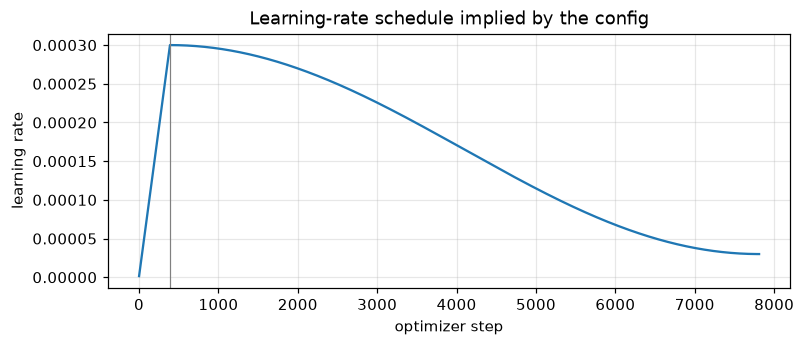

In [28]:
tcfg = cfg["training"]
if cfg["data"]["split_unit"] == "sequences":
    steps_per_epoch = cfg["data"]["train_size"] // tcfg["batch_size"]  # the training loader uses drop_last=True
    total_steps = steps_per_epoch * tcfg["epochs"]
    warmup_steps = (tcfg["warmup_steps"] if tcfg["warmup_steps"] is not None
                    else int(round(tcfg["warmup_ratio"] * total_steps)))
    sched_opt = torch.optim.SGD([nn.Parameter(torch.zeros(1))], lr=tcfg["learning_rate"])
    sched = build_scheduler(sched_opt, warmup_steps, total_steps, tcfg["min_lr_ratio"])
    lrs = []
    for _ in range(total_steps):
        sched_opt.step()
        sched.step()
        lrs.append(sched.get_last_lr()[0])
    print(f"{steps_per_epoch} steps per epoch, {total_steps} steps in total, {warmup_steps} warm-up steps")
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(range(1, total_steps + 1), lrs)
    ax.axvline(warmup_steps, color="grey", lw=0.8)
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("learning rate")
    ax.set_title("Learning-rate schedule implied by the config")
    ax.grid(alpha=0.3)
    show_fig(fig)

## 9. Training loop

`train_main` runs the complete experiment for one config file:

1. Seed everything, set up the raw log, build the split and tokenizer, and save the processed data.
2. Build the model, AdamW, the warm-up + cosine schedule, and mixed precision.
3. For each epoch: train with gradient clipping, skip any step whose loss or gradient is non-finite, track gradient norms and loss spikes, then evaluate on the validation windows.
4. Save `latest.pt` every epoch (with optimizer and scheduler state) and `best.pt` whenever the validation loss improves.
5. Write the per-step history, the loss-curve figure, the training summary, a first metrics report, `pip freeze`, and a manifest with the config, environment, and artifact paths.

It takes a command-line style argument list (`train_parse_args`), so the run is described by one config path. It is called in section 12.

In [29]:
def train_parse_args(argv=None):
    p = argparse.ArgumentParser(description="Train the Task 1 character-level GPT")
    p.add_argument("--config", required=True)
    p.add_argument("--smoke", action="store_true", help="Apply the smoke overrides from the config")
    p.add_argument("--epochs", type=int, default=None)
    p.add_argument("--batch_size", type=int, default=None)
    p.add_argument("--run_name", default=None)
    return p.parse_args(argv)

In [30]:
def train_main(argv=None) -> dict:
    args = train_parse_args(argv)
    cfg = load_config(args.config, smoke=args.smoke)
    if args.epochs is not None:
        cfg["training"]["epochs"] = args.epochs
    if args.batch_size is not None:
        cfg["training"]["batch_size"] = args.batch_size
    if args.run_name:
        cfg["run_name"] = args.run_name

    seed = int(cfg["seed"])
    set_seed(seed)
    tcfg, dcfg, paths_cfg = cfg["training"], cfg["data"], cfg["paths"]
    run_id = f"{cfg.get('run_name', 'task1')}{'_smoke' if cfg['is_smoke'] else ''}_{utc_timestamp()}"
    paths = {k: resolve_path(v) for k, v in paths_cfg.items()}
    for key in ("checkpoint_dir", "figures_dir", "logs_dir", "outputs_dir", "raw_log_dir", "manifest_dir"):
        paths[key].mkdir(parents=True, exist_ok=True)

    raw_log_path = paths["raw_log_dir"] / f"task1_parth_{run_id}.log"
    log = setup_logger(raw_log_path)
    log.info("run_id=%s", run_id)
    log.info("resolved config:\n%s", yaml.safe_dump(cfg, sort_keys=False))

    device = get_device()
    env = collect_environment()
    hardware = env.get("gpu_name") if device.type == "cuda" else f"CPU ({env.get('cpu')})"
    log.info("device=%s hardware=%s torch=%s cuda_build=%s", device, hardware, env["torch"],
             env["torch_cuda_build"])
    if device.type == "cuda" and tcfg.get("allow_tf32", True):
        torch.set_float32_matmul_precision("high")

    # ---------------------------------------------------------------- data
    T = int(cfg["model"]["context_length"])
    t_data = time.perf_counter()
    data = build_datasets(dcfg, context_length=T, seed=seed)
    tokenizer, train_ds, val_ds, meta = data["tokenizer"], data["train_ds"], data["val_ds"], data["meta"]
    meta["run_id"] = run_id
    tok_path = resolve_path(dcfg["tokenizer_path"])
    tokenizer.save(tok_path)
    save_processed(dcfg["processed_dir"], data["train_ids"], data["val_ids"], meta)
    log.info("data prepared in %.1fs: %s", time.perf_counter() - t_data, meta)
    log.info("tokenizer saved to %s (vocab_size=%d)", repo_relative(tok_path), tokenizer.vocab_size)

    bs = int(tcfg["batch_size"])
    workers = int(tcfg.get("num_workers", 0))
    pin = device.type == "cuda"
    train_loader = make_dataloader(train_ds, bs, True, seed, workers, pin, drop_last=True)
    val_loader = make_dataloader(val_ds, bs, False, seed, workers, pin, drop_last=False)
    if len(train_loader) == 0:
        raise ValueError(f"batch_size={bs} is larger than the {len(train_ds)} training windows")

    # ---------------------------------------------------------------- model / optim
    model_cfg = GPTConfig.from_dict(cfg["model"], vocab_size=tokenizer.vocab_size)
    model = GPTLanguageModel(model_cfg).to(device)
    n_params = model.count_parameters()
    log.info("model config: %s", model_cfg.to_dict())
    log.info("parameter count: %s", f"{n_params:,}")

    optimizer = model.configure_optimizer(float(tcfg["learning_rate"]), float(tcfg["weight_decay"]),
                                          tcfg.get("betas", [0.9, 0.95]))
    epochs = int(tcfg["epochs"])
    steps_per_epoch = len(train_loader)
    total_steps = epochs * steps_per_epoch
    warmup_steps = tcfg.get("warmup_steps")
    if warmup_steps is None:
        warmup_steps = int(round(float(tcfg.get("warmup_ratio", 0.05)) * total_steps))
    warmup_steps = int(min(warmup_steps, total_steps))
    scheduler = build_scheduler(optimizer, warmup_steps, total_steps, float(tcfg.get("min_lr_ratio", 0.1)))
    amp_enabled, amp_dtype, use_scaler = amp_settings(device, bool(tcfg.get("amp", True)),
                                                      tcfg.get("amp_dtype", "auto"))
    scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)
    grad_clip = float(tcfg.get("grad_clip", 1.0) or 0.0)
    spike_factor = float(tcfg.get("spike_factor", 2.0))
    log_interval = int(tcfg.get("log_interval", 50))
    log.info("steps/epoch=%d total_steps=%d warmup_steps=%d amp=%s dtype=%s grad_scaler=%s",
             steps_per_epoch, total_steps, warmup_steps, amp_enabled, amp_dtype, use_scaler)

    # ---------------------------------------------------------------- bookkeeping
    history = {"step": [], "train_loss_step": [], "lr_step": [], "grad_norm_step": [],
               "epoch": [], "train_loss_epoch": [], "val_loss_epoch": [], "val_acc_epoch": [],
               "epoch_time_sec": [], "epoch_tokens_per_sec": []}
    nan_loss_steps = nonfinite_grad_steps = spike_steps = clipped_steps = 0
    grad_norms: list[float] = []
    loss_ema = None
    global_step = 0
    train_tokens = 0
    train_compute_sec = 0.0
    best_val, best_epoch = float("inf"), None
    ckpt_dir = paths["checkpoint_dir"]
    history_path = paths["logs_dir"] / f"history_{run_id}.json"
    figure_path = paths["figures_dir"] / "task1_loss_curve.png"
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
    run_start = time.perf_counter()

    # ---------------------------------------------------------------- training loop
    for epoch in range(1, epochs + 1):
        model.train()
        if device.type == "cuda":
            torch.cuda.synchronize()
        t_epoch = time.perf_counter()
        epoch_loss_sum, epoch_batches, epoch_tokens = 0.0, 0, 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)  # (B, T)
            y = y.to(device, non_blocking=True)  # (B, T)
            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=amp_enabled):
                _, loss = model(x, y)
            loss_val = loss.item()
            global_step += 1

            if not math.isfinite(loss_val):
                nan_loss_steps += 1
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
                log.warning("non-finite loss at step %d (epoch %d); step skipped", global_step, epoch)
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)  # no-op without fp16 scaling; needed so clipping sees true grads
            max_norm = grad_clip if grad_clip > 0 else float("inf")
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm).item()

            if math.isfinite(grad_norm):
                if grad_clip > 0 and grad_norm > grad_clip:
                    clipped_steps += 1
                grad_norms.append(grad_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                nonfinite_grad_steps += 1
                if use_scaler:
                    # GradScaler detects the inf, skips the update, and lowers the loss scale.
                    scaler.step(optimizer)
                    scaler.update()
                log.warning("non-finite grad norm at step %d; optimizer update skipped", global_step)
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

            if loss_ema is not None and loss_val > spike_factor * loss_ema:
                spike_steps += 1
                log.warning("loss spike at step %d: %.4f vs EMA %.4f", global_step, loss_val, loss_ema)
            loss_ema = loss_val if loss_ema is None else 0.98 * loss_ema + 0.02 * loss_val

            lr_now = scheduler.get_last_lr()[0]
            history["step"].append(global_step)
            history["train_loss_step"].append(loss_val)
            history["lr_step"].append(lr_now)
            history["grad_norm_step"].append(grad_norm if math.isfinite(grad_norm) else None)
            epoch_loss_sum += loss_val
            epoch_batches += 1
            epoch_tokens += y.numel()

            if global_step % log_interval == 0 or global_step == 1:
                log.info("epoch %d step %d/%d | loss %.4f | lr %.3e | grad_norm %.3f",
                         epoch, global_step, total_steps, loss_val, lr_now, grad_norm)

        if device.type == "cuda":
            torch.cuda.synchronize()
        epoch_sec = time.perf_counter() - t_epoch
        train_compute_sec += epoch_sec
        train_tokens += epoch_tokens
        train_loss_epoch = epoch_loss_sum / max(1, epoch_batches)

        val = evaluate_lm(model, val_loader, device, amp_enabled, amp_dtype)
        history["epoch"].append(epoch)
        history["train_loss_epoch"].append(train_loss_epoch)
        history["val_loss_epoch"].append(val["loss"])
        history["val_acc_epoch"].append(val["accuracy"])
        history["epoch_time_sec"].append(epoch_sec)
        history["epoch_tokens_per_sec"].append(epoch_tokens / epoch_sec if epoch_sec > 0 else None)

        improved = val["loss"] < best_val
        if improved:
            best_val, best_epoch = val["loss"], epoch
        common = dict(model=model, cfg=cfg, model_cfg=model_cfg, tokenizer=tokenizer, run_id=run_id,
                      epoch=epoch, global_step=global_step, val_loss=val["loss"],
                      train_loss=train_loss_epoch, best_val_loss=best_val, seed=seed)
        save_checkpoint(ckpt_dir / "latest.pt", **common, extra={
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "scaler_state": scaler.state_dict(),
        })
        if improved:
            save_checkpoint(ckpt_dir / "best.pt", **common)

        log.info("EPOCH %d/%d | train_loss %.4f | val_loss %.4f | val_ppl %.3f | val_bpc %.4f | "
                 "val_acc %.4f | %.0f tok/s | %.1fs%s",
                 epoch, epochs, train_loss_epoch, val["loss"], math.exp(val["loss"]),
                 val["loss"] / math.log(2), val["accuracy"],
                 epoch_tokens / epoch_sec if epoch_sec > 0 else float("nan"), epoch_sec,
                 " | new best -> best.pt" if improved else "")
        write_json(history_path, history)
        plot_loss_curves(history, figure_path)

    # ---------------------------------------------------------------- wrap up
    total_sec = time.perf_counter() - run_start
    peak_alloc = peak_reserved = None
    if device.type == "cuda":
        peak_alloc = torch.cuda.max_memory_allocated(device) / 1024**2
        peak_reserved = torch.cuda.max_memory_reserved(device) / 1024**2

    summary = {
        "run_id": run_id,
        "is_smoke": cfg["is_smoke"],
        "device": device.type,
        "hardware": hardware,
        "amp_enabled": amp_enabled,
        "amp_dtype": str(amp_dtype) if amp_enabled else "float32",
        "parameter_count": n_params,
        "epochs_completed": len(history["epoch"]),
        "steps_completed": global_step,
        "batch_size": bs,
        "context_length": T,
        "tokens_per_epoch": steps_per_epoch * bs * T,
        "train_tokens_total": train_tokens,
        "train_compute_time_sec": train_compute_sec,
        "train_tokens_per_sec": train_tokens / train_compute_sec if train_compute_sec > 0 else None,
        "total_training_time_sec": total_sec,
        "peak_gpu_memory_allocated_mb": peak_alloc,
        "peak_gpu_memory_reserved_mb": peak_reserved,
        "best_epoch": best_epoch,
        "best_val_loss": best_val,
        "final_train_loss_epoch_mean": history["train_loss_epoch"][-1] if history["epoch"] else None,
        "final_val_loss": history["val_loss_epoch"][-1] if history["epoch"] else None,
        "grad_clip": grad_clip,
        "grad_norm_mean": sum(grad_norms) / len(grad_norms) if grad_norms else None,
        "grad_norm_max": max(grad_norms) if grad_norms else None,
        "grad_clipped_fraction": clipped_steps / max(1, len(grad_norms)),
        "nan_loss_steps": nan_loss_steps,
        "nonfinite_grad_steps": nonfinite_grad_steps,
        "loss_spike_steps": spike_steps,
        "spike_factor": spike_factor,
        "warmup_steps": warmup_steps,
        "total_steps": total_steps,
        "split": meta,
        "artifacts": {
            "best_checkpoint": repo_relative(ckpt_dir / "best.pt"),
            "latest_checkpoint": repo_relative(ckpt_dir / "latest.pt"),
            "raw_log": repo_relative(raw_log_path),
            "history": repo_relative(history_path),
            "loss_curve": repo_relative(figure_path),
            "tokenizer": repo_relative(tok_path),
        },
        "finished_at": utc_iso(),
    }
    summary_path = write_json(paths["logs_dir"] / f"train_summary_{run_id}.json", summary)

    rows = build_metric_rows(summary, None, None)
    report_path = write_metrics_report(paths["metrics_report"], rows)

    freeze_path = paths["manifest_dir"] / f"task1_parth_{run_id}_pip_freeze.txt"
    freeze_path.write_text(pip_freeze() + "\n", encoding="utf-8")
    manifest_path = write_json(paths["manifest_dir"] / f"task1_parth_{run_id}.json", {
        "run_id": run_id,
        "task": "task1_llm",
        "member": "parth",
        "command": "python task1_llm/parth/src/train.py " + " ".join(sys.argv[1:]) if argv is None
                   else "train.main(" + " ".join(argv) + ")",
        "created_at": utc_iso(),
        "git": git_info(),
        "environment": env,
        "pip_freeze_file": repo_relative(freeze_path),
        "config": cfg,
        "model_config": model_cfg.to_dict(),
        "data_split": meta,
        "checkpoint_map": {
            "best": {"path": summary["artifacts"]["best_checkpoint"], "epoch": best_epoch,
                     "val_loss": best_val, "used_for": "metrics_report.csv, generated samples"},
            "latest": {"path": summary["artifacts"]["latest_checkpoint"], "epoch": len(history["epoch"])},
        },
        "artifacts": {**summary["artifacts"], "summary": repo_relative(summary_path),
                      "metrics_report": repo_relative(report_path)},
    })

    log.info("training finished in %.1fs | best epoch %s val_loss %.4f | %.0f train tok/s | peak mem %s MB",
             total_sec, best_epoch, best_val, summary["train_tokens_per_sec"] or float("nan"),
             f"{peak_alloc:.1f}" if peak_alloc is not None else "NA")
    log.info("summary: %s", repo_relative(summary_path))
    log.info("manifest: %s", repo_relative(manifest_path))
    log.info("metrics report (training-side only, run evaluate.py next): %s", repo_relative(report_path))
    for h in list(log.handlers):
        h.close()
        log.removeHandler(h)
    return summary

## 10. Evaluation

- **Cross-entropy** (train and validation): mean next-character loss in nats, weighted by token count, with the model in evaluation mode. The train value uses `eval_train_batches` batches of evenly spaced training windows.
- **Perplexity**: `exp(validation cross-entropy)`.
- **Bits per character**: `validation cross-entropy / ln 2`.
- **Generalization gap**: `validation cross-entropy - train cross-entropy`, both in evaluation mode.
- **Top-1 next-character accuracy**: fraction of positions where the most likely character is the true next one.
- **Distinct-1/2/3**: unique word n-grams divided by total word n-grams over the generated continuations (prompt excluded), per decoding setting.
- **Repeated 4-gram rate**: share of 4-grams in a sample that already appeared earlier in the same sample, averaged over samples.
- **Stability, cost, and memory**: gradient norms, clipped, non-finite, and spiking steps, parameter count, training and generation throughput, peak GPU memory, and training time, from the training summary and the sample records.

`evaluate_main` loads `best.pt`, rebuilds the evaluation windows, computes all metrics, and writes `metrics_report.csv` and `eval_results.json`.

In [31]:
NEEDS_RUN = "NEEDS_RUN"


NA = "NA"


REPORT_COLUMNS = ["metric", "value", "unit", "split_or_setting", "source", "notes"]


@torch.no_grad()
def evaluate_lm(model, loader, device, amp_enabled: bool = False, amp_dtype=torch.float32,
                max_batches: int | None = None) -> dict:
    """Token-weighted mean cross-entropy (nats) and top-1 next-character accuracy."""
    was_training = model.training
    model.eval()
    loss_sum, correct, tokens = 0.0, 0, 0
    for b, (x, y) in enumerate(loader):
        if max_batches is not None and b >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=amp_enabled):
            logits, _ = model(x)  # (B, T, V)
        logits = logits.float()
        V = logits.size(-1)
        # Why: summing per-token losses and dividing by the token count gives the exact
        # per-character mean even when the final batch is smaller than the rest.
        loss_sum += F.cross_entropy(logits.view(-1, V), y.view(-1), reduction="sum").item()
        correct += (logits.argmax(dim=-1) == y).sum().item()
        tokens += y.numel()
    model.train(was_training)
    if tokens == 0:
        return {"loss": float("nan"), "accuracy": float("nan"), "tokens": 0}
    return {"loss": loss_sum / tokens, "accuracy": correct / tokens, "tokens": tokens}

In [32]:
def _ngrams(tokens: list[str], n: int) -> list[tuple]:
    return [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]


def distinct_n(token_lists: list[list[str]], n: int) -> float | None:
    """Corpus-level distinct-n: unique n-grams / total n-grams across all samples."""
    all_ngrams = [g for toks in token_lists for g in _ngrams(toks, n)]
    return len(set(all_ngrams)) / len(all_ngrams) if all_ngrams else None


def repeated_ngram_rate(token_lists: list[list[str]], n: int = 4) -> float | None:
    """Share of n-gram occurrences that repeat an earlier n-gram within the same sample."""
    repeats, total = 0, 0
    for toks in token_lists:
        grams = _ngrams(toks, n)
        total += len(grams)
        repeats += len(grams) - len(set(grams))
    return repeats / total if total else None


def generation_metrics(jsonl_path: Path) -> dict | None:
    """Diversity and speed per decoding setting; None if no samples exist yet."""
    if not jsonl_path.exists():
        return None
    records = [json.loads(line) for line in jsonl_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    if not records:
        return None
    groups: dict[str, list[dict]] = {}
    for r in records:
        groups.setdefault(r.get("decoding", "unknown"), []).append(r)
    out = {}
    for label, recs in groups.items():
        # Why: diversity is measured on the generated continuation only, at word level
        # (whitespace split), since character n-grams mostly measure spelling, not repetition.
        words = [r["continuation"].split() for r in recs]
        new_tokens = sum(r["new_tokens"] for r in recs)
        seconds = sum(r["seconds"] for r in recs)
        out[label] = {
            "num_samples": len(recs),
            "distinct_1": distinct_n(words, 1),
            "distinct_2": distinct_n(words, 2),
            "distinct_3": distinct_n(words, 3),
            "repeated_4gram_rate": repeated_ngram_rate(words, 4),
            "generation_tokens_per_sec": new_tokens / seconds if seconds > 0 else None,
            "devices": sorted({r.get("device", "unknown") for r in recs}),
            "run_ids": sorted({str(r.get("run_id")) for r in recs}),
        }
    return out

In [33]:
def _fmt(value, digits: int = 6):
    if value is None:
        return NEEDS_RUN
    if isinstance(value, float):
        if math.isnan(value) or math.isinf(value):
            return str(value)
        return round(value, digits)
    return value


def build_metric_rows(summary: dict | None, eval_results: dict | None,
                      gen_results: dict | None) -> list[dict]:
    """Assemble metrics_report.csv rows. Missing inputs become NEEDS_RUN, never guesses."""
    s = summary or {}
    e = eval_results or {}
    rows: list[dict] = []

    def add(metric, value, unit="", split="", source="", notes=""):
        rows.append({"metric": metric, "value": _fmt(value), "unit": unit,
                     "split_or_setting": split, "source": source, "notes": notes})

    ckpt_src = f"evaluate.py on {e.get('checkpoint', 'checkpoint')}" if e else "evaluate.py"
    train_loss = e.get("train_loss")
    val_loss = e.get("val_loss")

    add("train_cross_entropy", train_loss, "nats/char", "train (eval mode, subset)", ckpt_src,
        f"{e.get('train_tokens_evaluated', NEEDS_RUN)} tokens, dropout off")
    add("train_cross_entropy_epoch_mean", s.get("final_train_loss_epoch_mean"), "nats/char",
        "train (final epoch, dropout on)", "train.py summary", "running mean over the last epoch")
    add("val_cross_entropy", val_loss, "nats/char", "validation (full)", ckpt_src,
        f"{e.get('val_tokens_evaluated', NEEDS_RUN)} tokens")
    add("perplexity", math.exp(val_loss) if val_loss is not None else None, "", "validation",
        ckpt_src, "exp(val_cross_entropy)")
    add("bits_per_character", val_loss / math.log(2) if val_loss is not None else None, "bits/char",
        "validation", ckpt_src, "val_cross_entropy / ln(2)")
    gap = (val_loss - train_loss) if (val_loss is not None and train_loss is not None) else None
    add("generalization_gap", gap, "nats/char", "val - train", ckpt_src, "both measured in eval mode")
    add("top1_next_char_accuracy", e.get("val_accuracy"), "fraction", "validation", ckpt_src)
    add("top1_next_char_accuracy", e.get("train_accuracy"), "fraction", "train (eval mode, subset)", ckpt_src)

    if gen_results:
        for label, g in gen_results.items():
            src = "evaluate.py on generated_samples.jsonl"
            note = f"{g['num_samples']} samples, word-level, continuation only"
            add("distinct_1", g["distinct_1"], "fraction", label, src, note)
            add("distinct_2", g["distinct_2"], "fraction", label, src, note)
            add("distinct_3", g["distinct_3"], "fraction", label, src, note)
            add("repeated_4gram_rate", g["repeated_4gram_rate"], "fraction", label, src, note)
            add("generation_tokens_per_sec", g["generation_tokens_per_sec"], "chars/sec", label, src,
                f"device={','.join(g['devices'])}, batch size 1, no KV cache")
    else:
        for metric in ("distinct_1", "distinct_2", "distinct_3", "repeated_4gram_rate",
                       "generation_tokens_per_sec"):
            add(metric, None, "", "generation", "generate.py", "run generate.py first")

    tsrc = "train.py summary"
    add("grad_norm_mean", s.get("grad_norm_mean"), "L2", "train", tsrc, "pre-clip global norm")
    add("grad_norm_max", s.get("grad_norm_max"), "L2", "train", tsrc, "pre-clip global norm")
    add("grad_clipped_step_fraction", s.get("grad_clipped_fraction"), "fraction", "train", tsrc,
        f"grad_clip={s.get('grad_clip', NEEDS_RUN)}")
    add("nan_loss_steps", s.get("nan_loss_steps"), "count", "train", tsrc, "non-finite loss, step skipped")
    add("nonfinite_grad_steps", s.get("nonfinite_grad_steps"), "count", "train", tsrc,
        "fp16 loss-scale overflows land here; bf16/fp32 should be 0")
    add("loss_spike_steps", s.get("loss_spike_steps"), "count", "train", tsrc,
        f"loss > {s.get('spike_factor', NEEDS_RUN)} x EMA of recent loss")
    add("parameter_count", e.get("parameter_count", s.get("parameter_count")), "params", "model", ckpt_src)
    add("train_tokens_per_sec", s.get("train_tokens_per_sec"), "chars/sec", "train", tsrc,
        "training steps only, validation passes excluded")

    on_cuda = s.get("device") == "cuda" if s else None
    mem_val = s.get("peak_gpu_memory_allocated_mb") if on_cuda else (NA if s else None)
    add("peak_gpu_memory_allocated", mem_val, "MB", "train", tsrc, "torch.cuda.max_memory_allocated")
    mem_res = s.get("peak_gpu_memory_reserved_mb") if on_cuda else (NA if s else None)
    add("peak_gpu_memory_reserved", mem_res, "MB", "train", tsrc, "torch.cuda.max_memory_reserved")
    add("total_training_time", s.get("total_training_time_sec"), "seconds", "train", tsrc,
        "wall clock, includes per-epoch validation and checkpointing")
    add("epochs_completed", s.get("epochs_completed"), "epochs", "train", tsrc)
    add("best_epoch", s.get("best_epoch"), "epoch", "train", tsrc, "epoch with lowest val loss")
    add("hardware", s.get("hardware"), "", "train", tsrc)
    add("run_id", s.get("run_id") or e.get("run_id"), "", "", tsrc)
    return rows


def write_metrics_report(path, rows: list[dict]) -> Path:
    return write_csv(path, rows, REPORT_COLUMNS)

In [34]:
def evaluate_parse_args(argv=None):
    p = argparse.ArgumentParser(description="Evaluate a Task 1 checkpoint")
    p.add_argument("--checkpoint", required=True)
    p.add_argument("--config", required=True)
    p.add_argument("--samples", default=None, help="generated_samples.jsonl (defaults to outputs dir)")
    p.add_argument("--max_train_batches", type=int, default=None)
    p.add_argument("--smoke", action="store_true", help="Use the smoke overrides in train.yaml")
    return p.parse_args(argv)

In [35]:
def evaluate_main(argv=None) -> dict:
    args = evaluate_parse_args(argv)
    cfg = load_config(args.config, smoke=args.smoke)
    device = get_device()
    model, tokenizer, ckpt = load_checkpoint(args.checkpoint, device)
    run_id = ckpt.get("run_id")
    seed = int(ckpt.get("seed", cfg["seed"]))
    set_seed(seed)
    tcfg = cfg["training"]
    paths = cfg["paths"]
    T = model.config.context_length

    # Why: the split is rebuilt from the checkpoint's own data config and seed, not the
    # current YAML, so evaluation always sees exactly the split the model trained against.
    data_cfg = ckpt["train_config"]["data"]
    cached = load_processed(data_cfg["processed_dir"])
    if cached is not None and cached[2].get("run_id") == run_id:
        train_ids, val_ids, meta = cached
        stride = int(meta["window_stride"])
        cap = int(meta["train_size_requested"]) if meta["split_unit"] == "sequences" else None
        vcap = int(meta["val_size_requested"]) if meta["split_unit"] == "sequences" else None
        train_ds = CharWindowDataset(train_ids, T, stride, cap)
        val_ds = CharWindowDataset(val_ids, T, stride, vcap)
        split_source = "data_processed cache (run_id match)"
    else:
        built = build_datasets(data_cfg, context_length=T, seed=seed, tokenizer=tokenizer)
        train_ds, val_ds = built["train_ds"], built["val_ds"]
        split_source = "rebuilt from checkpoint data config"

    bs = int(tcfg["batch_size"])
    workers = int(tcfg.get("num_workers", 0))
    pin = device.type == "cuda"
    max_train_batches = args.max_train_batches or int(tcfg.get("eval_train_batches", 100))
    n_train = min(len(train_ds), max_train_batches * bs)
    # Why: evenly spaced windows cover the whole training stream instead of only its start.
    step = max(1, len(train_ds) // n_train)
    train_subset = Subset(train_ds, list(range(0, len(train_ds), step))[:n_train])
    train_loader = make_dataloader(train_subset, bs, False, seed, workers, pin)
    val_loader = make_dataloader(val_ds, bs, False, seed, workers, pin)

    amp_enabled, amp_dtype, _ = amp_settings(device, bool(tcfg.get("amp", True)), tcfg.get("amp_dtype", "auto"))
    val = evaluate_lm(model, val_loader, device, amp_enabled, amp_dtype)
    train = evaluate_lm(model, train_loader, device, amp_enabled, amp_dtype)

    summary_path = resolve_path(paths["logs_dir"]) / f"train_summary_{run_id}.json"
    summary = read_json(summary_path) if summary_path.exists() else None
    samples = resolve_path(args.samples) if args.samples else \
        resolve_path(paths["outputs_dir"]) / "generated_samples.jsonl"
    gen = generation_metrics(samples)
    if gen:
        foreign = {rid for g in gen.values() for rid in g["run_ids"]} - {str(run_id)}
        if foreign:
            print(f"[warn] samples file contains other run_ids {sorted(foreign)}; regenerate before reporting")

    eval_results = {
        "run_id": run_id,
        "checkpoint": repo_relative(resolve_path(args.checkpoint)),
        "checkpoint_epoch": ckpt.get("epoch"),
        "split_source": split_source,
        "val_loss": val["loss"],
        "val_accuracy": val["accuracy"],
        "val_tokens_evaluated": val["tokens"],
        "train_loss": train["loss"],
        "train_accuracy": train["accuracy"],
        "train_tokens_evaluated": train["tokens"],
        "parameter_count": model.count_parameters(),
        "amp_dtype": str(amp_dtype) if amp_enabled else "float32",
        "device": device.type,
        "evaluated_at": utc_iso(),
    }
    rows = build_metric_rows(summary, eval_results, gen)
    report_path = write_metrics_report(paths["metrics_report"], rows)
    outputs_dir = resolve_path(paths["outputs_dir"])
    write_json(outputs_dir / "eval_results.json", {"eval": eval_results, "generation": gen})
    write_json(resolve_path(paths["manifest_dir"]) / f"task1_parth_{run_id}_eval_{utc_timestamp()}.json", {
        "run_id": run_id,
        "checkpoint": eval_results["checkpoint"],
        "metrics_report": repo_relative(report_path),
        "samples_file": repo_relative(samples) if samples.exists() else None,
        "summary_file": repo_relative(summary_path) if summary_path.exists() else None,
        "eval": eval_results,
    })

    width = max(len(r["metric"]) for r in rows)
    for r in rows:
        print(f"{r['metric']:<{width}}  {str(r['value']):<14} {r['unit']:<10} {r['split_or_setting']}")
    print(f"\nWrote {repo_relative(report_path)}")
    return {"eval": eval_results, "generation": gen, "rows": rows}

## 11. Text generation

`GPTLanguageModel.generate` (section 7) produces one character at a time: crop the context to the last `context_length` characters, take the logits of the last position, and pick the next character greedily or by sampling with temperature and top-k. `generate_main` loads a checkpoint, generates `num_samples` continuations per prompt, and appends them to a `.txt` and a `.jsonl` file. Sample `s` of prompt `p` uses the seed `seed + 1000 x p + s`.

In [36]:
DEFAULT_OUTPUT = "task1_llm/parth/outputs/generated_samples.txt"


def decoding_label(greedy: bool, temperature: float, top_k: int | None) -> str:
    if greedy or temperature <= 0:
        return "greedy"
    return f"temperature={temperature},top_k={top_k if top_k else 'none'}"


def generate_text(model: GPTLanguageModel, tokenizer: CharTokenizer, prompt: str,
                  max_new_tokens: int, temperature: float, top_k: int | None,
                  greedy: bool, device: torch.device) -> dict:
    if not prompt:
        raise ValueError("Prompt must contain at least one character")
    ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)  # (1, T0)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    out = model.generate(ids, max_new_tokens=max_new_tokens, temperature=temperature,
                         top_k=top_k, greedy=greedy)
    if device.type == "cuda":
        torch.cuda.synchronize()
    seconds = time.perf_counter() - t0
    new_ids = out[0, ids.size(1):].tolist()
    return {
        "prompt": prompt,
        "continuation": tokenizer.decode(new_ids),
        "text": tokenizer.decode(out[0].tolist()),
        "new_tokens": len(new_ids),
        "seconds": seconds,
        "tokens_per_sec": len(new_ids) / seconds if seconds > 0 else None,
        "unknown_prompt_chars": tokenizer.count_unknown(prompt),
    }

In [37]:
def generate_parse_args(argv=None):
    p = argparse.ArgumentParser(description="Generate text with the Task 1 character-level GPT")
    p.add_argument("--checkpoint", required=True)
    p.add_argument("--prompt", action="append", default=None,
                   help="Prompt text; pass several times for several prompts")
    p.add_argument("--max_new_tokens", type=int, default=500)
    p.add_argument("--temperature", type=float, default=0.8)
    p.add_argument("--top_k", type=int, default=50, help="0 disables top-k filtering")
    p.add_argument("--greedy", action="store_true", help="Greedy decoding (ignores temperature/top_k)")
    p.add_argument("--num_samples", type=int, default=1, help="Samples per prompt")
    p.add_argument("--seed", type=int, default=8503)
    p.add_argument("--output", default=DEFAULT_OUTPUT)
    p.add_argument("--append", action="store_true", help="Append instead of overwriting outputs")
    return p.parse_args(argv)

In [38]:
def generate_main(argv=None) -> list[dict]:
    args = generate_parse_args(argv)
    device = get_device()
    model, tokenizer, ckpt = load_checkpoint(args.checkpoint, device)
    prompts = args.prompt or ["Once upon a time"]
    top_k = args.top_k if args.top_k and args.top_k > 0 else None
    label = decoding_label(args.greedy, args.temperature, top_k)

    records = []
    for p_idx, prompt in enumerate(prompts):
        for s_idx in range(args.num_samples):
            # Why: a distinct, derived seed per sample makes every sample individually
            # reproducible from the command line without them all being identical.
            sample_seed = args.seed + 1000 * p_idx + s_idx
            set_seed(sample_seed)
            result = generate_text(model, tokenizer, prompt, args.max_new_tokens,
                                   args.temperature, top_k, args.greedy, device)
            result.update({
                "run_id": ckpt.get("run_id"),
                "checkpoint": repo_relative(resolve_path(args.checkpoint)),
                "checkpoint_epoch": ckpt.get("epoch"),
                "decoding": label,
                "temperature": None if label == "greedy" else args.temperature,
                "top_k": None if label == "greedy" else top_k,
                "seed": sample_seed,
                "sample_index": s_idx,
                "device": device.type,
                "created_at": utc_iso(),
            })
            records.append(result)
            if result["unknown_prompt_chars"]:
                print(f"[warn] prompt has {result['unknown_prompt_chars']} character(s) outside the vocabulary")

    txt_path = resolve_path(args.output)
    jsonl_path = txt_path.with_suffix(".jsonl")
    txt_path.parent.mkdir(parents=True, exist_ok=True)
    mode = "a" if args.append else "w"
    with open(txt_path, mode, encoding="utf-8") as f:
        for r in records:
            f.write(
                f"===== run={r['run_id']} | ckpt={r['checkpoint']} (epoch {r['checkpoint_epoch']}) | "
                f"{r['decoding']} | seed={r['seed']} | new_tokens={r['new_tokens']} | "
                f"{r['tokens_per_sec']:.1f} tok/s =====\n"
            )
            f.write(f"PROMPT: {r['prompt']}\n")
            f.write(r["text"] + "\n\n")
    with open(jsonl_path, mode, encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    for r in records:
        print(f"\n--- {r['decoding']} | seed {r['seed']} | {r['tokens_per_sec']:.1f} tok/s ---")
        print(r["text"])
    print(f"\nWrote {len(records)} sample(s) to {repo_relative(txt_path)} and {repo_relative(jsonl_path)}")
    return records

The decoding settings of the reported samples: two prompts with temperature 0.8 and top-k 50 (three samples each), and one greedy sample, 500 new characters each, base seed 8503. The cell checks them against the reported `generated_samples.jsonl` when it is present.

In [39]:
GENERATION_RUNS = [
    ["--prompt", "Once upon a time", "--prompt", "Tom had a red ball", "--num_samples", "3",
     "--max_new_tokens", "500", "--temperature", "0.8", "--top_k", "50", "--seed", str(SEED)],
    ["--prompt", "Once upon a time", "--num_samples", "1", "--max_new_tokens", "500", "--greedy", "--seed", str(SEED)],
]


def planned_samples(runs):
    """(prompt, decoding label, seed, new characters) of every sample the runs above produce."""
    out = []
    for argv in runs:
        a = generate_parse_args(["--checkpoint", "-", *argv])
        top_k = a.top_k if a.top_k and a.top_k > 0 else None
        for p_idx, prompt in enumerate(a.prompt):
            for s_idx in range(a.num_samples):
                out.append((prompt, decoding_label(a.greedy, a.temperature, top_k),
                            a.seed + 1000 * p_idx + s_idx, a.max_new_tokens))
    return out


show_table(planned_samples(GENERATION_RUNS), columns=["prompt", "decoding", "seed", "new characters"])
reported_samples_path = MEMBER_DIR / "outputs" / "generated_samples.jsonl"
if reported_samples_path.exists():
    reported_records = [json.loads(l) for l in reported_samples_path.read_text(encoding="utf-8").splitlines() if l.strip()]
    reported_plan = [(r["prompt"], r["decoding"], r["seed"], r["new_tokens"]) for r in reported_records]
    print("identical to the settings of the reported samples:", reported_plan == planned_samples(GENERATION_RUNS))

,prompt,decoding,seed,new characters
0,Once upon a time,"temperature=0.8,top_k=50",8503,500
1,Once upon a time,"temperature=0.8,top_k=50",8504,500
2,Once upon a time,"temperature=0.8,top_k=50",8505,500
3,Tom had a red ball,"temperature=0.8,top_k=50",9503,500
4,Tom had a red ball,"temperature=0.8,top_k=50",9504,500
5,Tom had a red ball,"temperature=0.8,top_k=50",9505,500
6,Once upon a time,greedy,8503,500


identical to the settings of the reported samples: True


## 12. Execute the experiment

Training, generation, and evaluation, in that order, on the config written in section 3. With `RUN_MODE = "full"` this is the reported experiment (10 epochs; the reported run spent 92 seconds in training and validation on an RTX 5090). The training log is printed below the cell and saved in the run folder.

In [40]:
train_argv = ["--config", CONFIG_PATH] + (["--smoke"] if SMOKE else [])
summary = train_main(train_argv)

2026-10-02 15:02:41 | INFO | run_id=parth_gpt_char_v1_20261002T220241Z
2026-10-02 15:02:41 | INFO | resolved config:
run_name: parth_gpt_char_v1
seed: 8503
model_config: task1_llm/parth/notebook_runs/gpu_run/config/model.yaml
data:
  data_dir: task1_llm/data
  data_file: null
  max_stories_to_load: 80000
  story_separator: '


    '
  split_unit: sequences
  train_size: 100000
  val_size: 10000
  window_stride: null
  min_char_freq: 1
  processed_dir: task1_llm/parth/notebook_runs/gpu_run/data_processed
  tokenizer_path: task1_llm/parth/notebook_runs/gpu_run/data_processed/tokenizer.json
training:
  epochs: 10
  batch_size: 128
  learning_rate: 0.0003
  min_lr_ratio: 0.1
  weight_decay: 0.01
  betas:
  - 0.9
  - 0.95
  warmup_ratio: 0.05
  warmup_steps: null
  grad_clip: 1.0
  amp: true
  amp_dtype: auto
  allow_tf32: true
  num_workers: 2
  log_interval: 50
  spike_factor: 2.0
  eval_train_batches: 100
paths:
  checkpoint_dir: task1_llm/parth/notebook_runs/gpu_run/checkpoints
  figure

In [41]:
# train_main enables TF32 matmuls for the whole process; generation and evaluation originally ran in
# separate processes without it, so the default precision is restored first.
torch.set_float32_matmul_precision("highest")

BEST_CKPT = summary["artifacts"]["best_checkpoint"]
SAMPLES_TXT = f"{cfg['paths']['outputs_dir']}/generated_samples.txt"
SAMPLES_JSONL = SAMPLES_TXT[: -len(".txt")] + ".jsonl"
for i, gen_argv in enumerate(GENERATION_RUNS):
    generate_main(["--checkpoint", BEST_CKPT, *gen_argv, "--output", SAMPLES_TXT] + (["--append"] if i else []))


--- temperature=0.8,top_k=50 | seed 8503 | 467.8 tok/s ---
Once upon a time, there was a little girl named Mia. She had a big box with a ball in her box. She had a big box that she loved her car. Mia loved to play with her friends. One day, while they were playing, Mia saw a little boy named Tim. Tim was an old turtle boy who was very hot. He wanted to draw a big tree with his boat, so he went to the park and found a vase. He sat down rocks and ran outside with the trees and put it away around the forest? 
The girl was so excited that she couldn't believe her to show h

--- temperature=0.8,top_k=50 | seed 8504 | 530.9 tok/s ---
Once upon a time, there was a little boy named Tim. Tim had a big surprise that he loved very much. Every day, he would not share his room with his toys. One day, Tim went to the park with his mom. They walked to the park together. Tim threw the park and they found a toy to get the park. Tim was happy again.

Once upon a time, there was a small cat named Tom. T

In [42]:
eval_argv = ["--checkpoint", BEST_CKPT, "--config", CONFIG_PATH, "--samples", SAMPLES_JSONL] + (["--smoke"] if SMOKE else [])
eval_out = evaluate_main(eval_argv)

train_cross_entropy             0.718891       nats/char  train (eval mode, subset)
train_cross_entropy_epoch_mean  0.771349       nats/char  train (final epoch, dropout on)
val_cross_entropy               0.738079       nats/char  validation (full)
perplexity                      2.091913                  validation
bits_per_character              1.064823       bits/char  validation
generalization_gap              0.019188       nats/char  val - train
top1_next_char_accuracy         0.766218       fraction   validation
top1_next_char_accuracy         0.770704       fraction   train (eval mode, subset)
distinct_1                      0.345853       fraction   temperature=0.8,top_k=50
distinct_2                      0.721959       fraction   temperature=0.8,top_k=50
distinct_3                      0.874003       fraction   temperature=0.8,top_k=50
repeated_4gram_rate             0.004831       fraction   temperature=0.8,top_k=50
generation_tokens_per_sec       518.241415     chars/sec 

## 13. Results and visualizations

Everything below is read from the files this notebook's run wrote in `notebook_runs/<RUN_TAG>/`.

**About the saved outputs.** This notebook was executed end to end on the RTX 5090 on 2 October 2026 (`RUN_MODE = "full"`, `RUN_TAG = "gpu_run"`) as a reproducibility and submission run. The training, evaluation and generation outputs in this notebook therefore come from that Oct 2 reproduction run, `parth_gpt_char_v1_20261002T220241Z` (validation CE 0.738079).

The project's reported result is still the preserved Sep 25 run `parth_gpt_char_v1_20260925T214701Z` and its checkpoint `task1_llm/parth/checkpoints/best.pt` (validation CE 0.739443, perplexity 2.094769, BPC 1.066791, accuracy 0.765526). The section "Re-evaluating the reported checkpoint" below re-evaluates that checkpoint: it reproduces the reported metrics up to floating-point differences (CE 0.739455) and regenerates all 7 reported samples identically.

In [43]:
history = read_json(resolve_path(summary["artifacts"]["history"]))
report = pd.read_csv(resolve_path(cfg["paths"]["metrics_report"]))
samples = [json.loads(l) for l in resolve_path(SAMPLES_JSONL).read_text(encoding="utf-8").splitlines() if l.strip()]
split = summary["split"]

keys = ["data_file", "split_unit", "seed", "stories_loaded", "train_stories", "val_stories", "train_chars",
        "val_chars", "context_length", "window_stride", "train_windows", "val_windows", "vocab_size",
        "tokenizer_fitted_on", "val_unknown_chars"]
show_table([(k, split.get(k)) for k in keys], columns=["data split", "value"])

,data split,value
0,data_file,task1_llm/data/TinyStoriesV2-GPT4-train.txt
1,split_unit,sequences
2,seed,8503
3,stories_loaded,80000
4,train_stories,15880
5,val_stories,1610
6,train_chars,12800004
7,val_chars,1280350
8,context_length,128
9,window_stride,128


### Loss curves

Per-epoch values from the history file. The epoch training loss is the mean over the epoch's steps with dropout on; the validation loss is computed in evaluation mode after the epoch. The figure is the one `plot_loss_curves` saved.

,epoch,train loss (epoch mean),val loss,val perplexity,val bits/char,val top-1 accuracy,epoch time (s),train chars/s
0,1,2.0049,1.2173,3.3782,1.7562,0.6261,9.5468,1.340333e+06
1,2,1.1376,0.9569,2.6036,1.3805,0.7008,8.8070,1.452926e+06
2,3,0.9727,0.8731,2.3943,1.2596,0.7251,8.5610,1.494679e+06
3,4,0.9009,0.8256,2.2833,1.1911,0.7392,8.7246,1.466651e+06
4,5,0.8572,0.7972,2.2193,1.1501,0.7479,8.6601,1.477572e+06
5,6,0.8274,0.7748,2.1701,1.1178,0.7546,8.4728,1.510234e+06
6,7,0.8057,0.7600,2.1383,1.0965,0.7589,8.5576,1.495259e+06
7,8,0.7894,0.7492,2.1154,1.0809,0.7624,8.5181,1.502209e+06
8,9,0.7784,0.7424,2.1010,1.0711,0.7647,8.4649,1.511647e+06
9,10,0.7713,0.7381,2.0919,1.0648,0.7662,8.4819,1.508609e+06


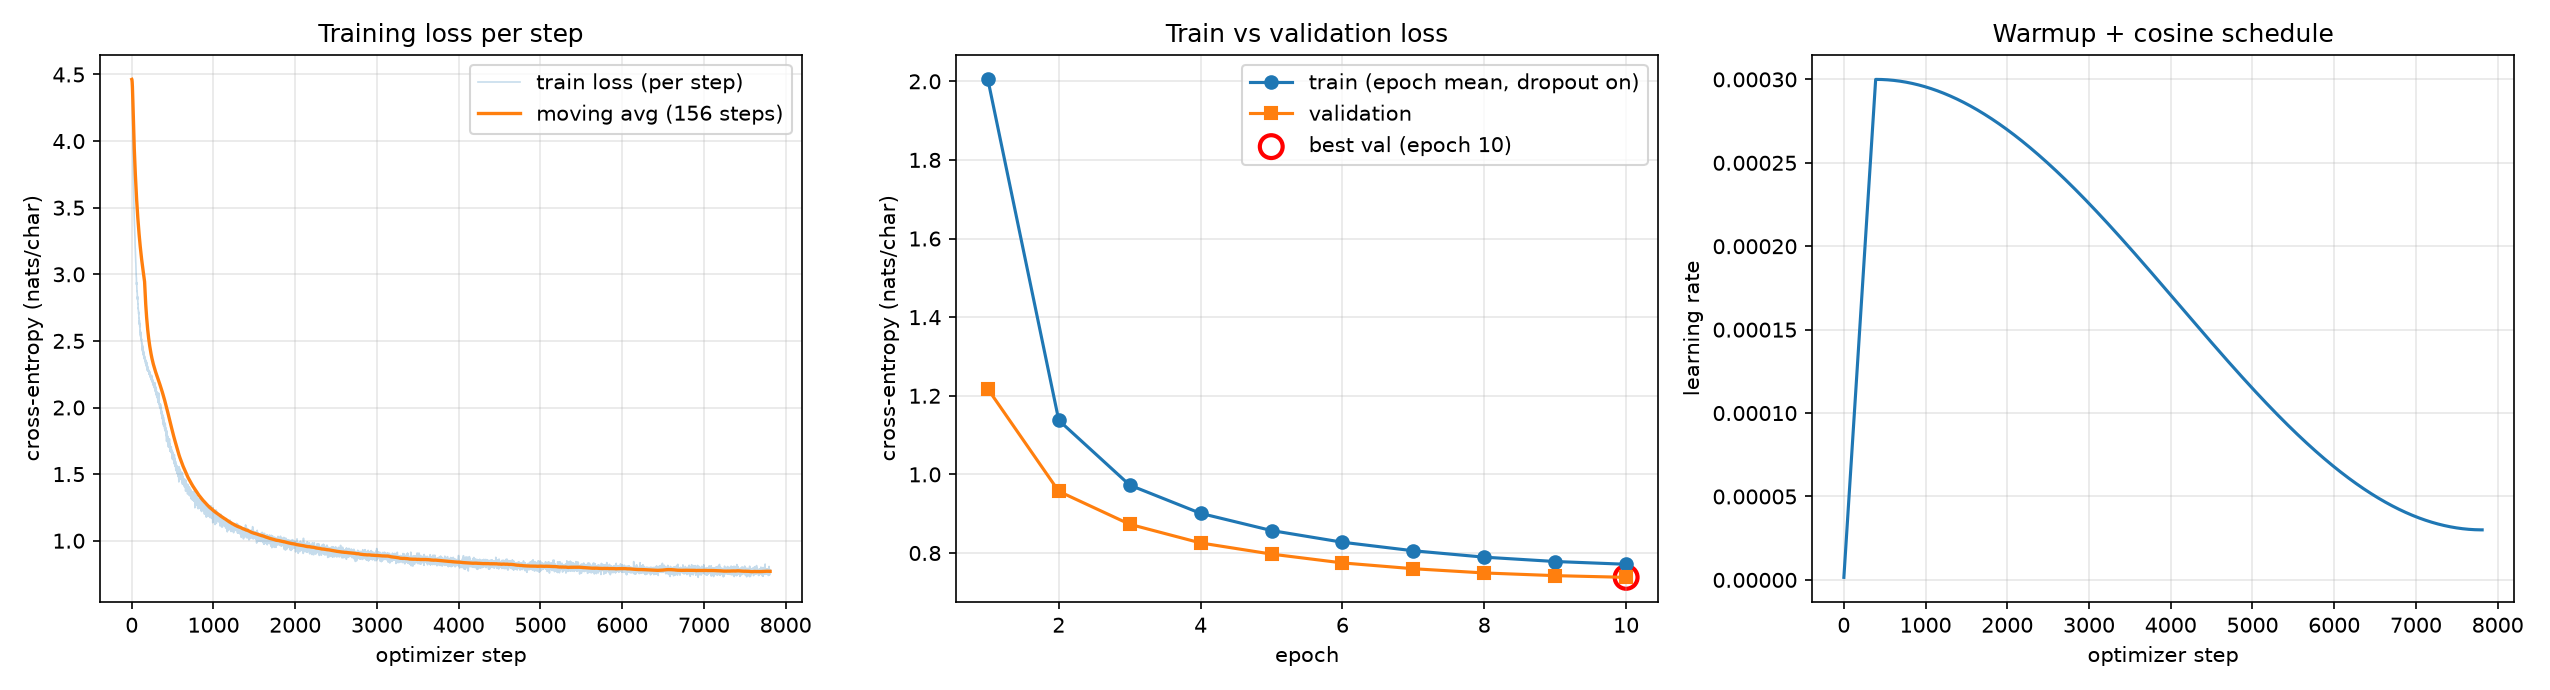

In [44]:
display(pd.DataFrame({
    "epoch": history["epoch"],
    "train loss (epoch mean)": history["train_loss_epoch"],
    "val loss": history["val_loss_epoch"],
    "val perplexity": np.exp(history["val_loss_epoch"]),
    "val bits/char": np.array(history["val_loss_epoch"]) / math.log(2),
    "val top-1 accuracy": history["val_acc_epoch"],
    "epoch time (s)": history["epoch_time_sec"],
    "train chars/s": history["epoch_tokens_per_sec"],
}).round(4))
display(Image(filename=str(resolve_path(summary["artifacts"]["loss_curve"]))))

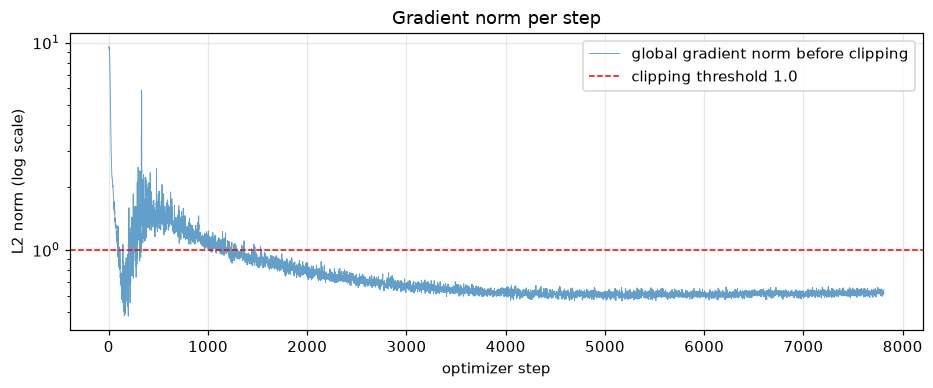

In [45]:
grad_norm = np.array([g if g is not None else np.nan for g in history["grad_norm_step"]], dtype=float)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(history["step"], grad_norm, lw=0.6, alpha=0.7, label="global gradient norm before clipping")
ax.axhline(summary["grad_clip"], color="red", ls="--", lw=1, label=f"clipping threshold {summary['grad_clip']}")
ax.set_yscale("log")
ax.set_xlabel("optimizer step")
ax.set_ylabel("L2 norm (log scale)")
ax.set_title("Gradient norm per step")
ax.legend()
ax.grid(alpha=0.3)
show_fig(fig)

### Training stability, cost, and memory

In [46]:
s = summary
show_table([
    ("run id", s["run_id"]),
    ("hardware", s["hardware"]),
    ("AMP dtype", s["amp_dtype"]),
    ("parameters", f"{s['parameter_count']:,}"),
    ("epochs / steps", f"{s['epochs_completed']} / {s['steps_completed']}"),
    ("best epoch (lowest val loss)", s["best_epoch"]),
    ("best val loss", s["best_val_loss"]),
    ("grad norm mean / max (before clipping)", f"{s['grad_norm_mean']:.4f} / {s['grad_norm_max']:.4f}"),
    ("fraction of steps clipped", s["grad_clipped_fraction"]),
    ("non-finite loss / gradient steps", f"{s['nan_loss_steps']} / {s['nonfinite_grad_steps']}"),
    ("loss spikes (> spike_factor x running mean)", s["loss_spike_steps"]),
    ("training characters processed", f"{s['train_tokens_total']:,}"),
    ("train chars/s (training steps only)", s["train_tokens_per_sec"]),
    ("time in training steps (s)", s["train_compute_time_sec"]),
    ("total training time incl. validation (s)", s["total_training_time_sec"]),
    ("peak GPU memory allocated / reserved (MB)",
     f"{s['peak_gpu_memory_allocated_mb']} / {s['peak_gpu_memory_reserved_mb']}"),
], columns=["item", "value"])

,item,value
0,run id,parth_gpt_char_v1_20261002T220241Z
1,hardware,NVIDIA GeForce RTX 5090
2,AMP dtype,torch.bfloat16
3,parameters,"3,233,792"
4,epochs / steps,10 / 7810
5,best epoch (lowest val loss),10
6,best val loss,0.738079
7,grad norm mean / max (before clipping),0.7721 / 9.5482
8,fraction of steps clipped,0.135083
9,non-finite loss / gradient steps,0 / 0


### Evaluation metrics

`metrics_report.csv` of this run, followed by a check that every expected metric is present and that the derived metrics are consistent with the losses and samples they come from.

In [47]:
display(report)

REQUIRED = {
    "Training cross-entropy loss": ["train_cross_entropy", "train_cross_entropy_epoch_mean"],
    "Validation cross-entropy loss": ["val_cross_entropy"],
    "Perplexity": ["perplexity"],
    "Bits-per-character": ["bits_per_character"],
    "Generalization gap": ["generalization_gap"],
    "Top-1 next-character accuracy": ["top1_next_char_accuracy"],
    "Distinct-1 / 2 / 3": ["distinct_1", "distinct_2", "distinct_3"],
    "Repeated 4-gram rate": ["repeated_4gram_rate"],
    "Gradient norm and training stability": ["grad_norm_mean", "grad_norm_max", "grad_clipped_step_fraction",
                                             "nan_loss_steps", "nonfinite_grad_steps", "loss_spike_steps"],
    "Parameter count": ["parameter_count"],
    "Training and generation tokens/sec": ["train_tokens_per_sec", "generation_tokens_per_sec"],
    "Peak memory and total training time": ["peak_gpu_memory_allocated", "peak_gpu_memory_reserved",
                                            "total_training_time"],
}
present = set(report["metric"])
show_table([(req, ", ".join(names), all(n in present for n in names)) for req, names in REQUIRED.items()],
           columns=["handout metric", "rows in metrics_report.csv", "present"])

,metric,value,unit,split_or_setting,source,notes
0,train_cross_entropy,0.718891,nats/char,"train (eval mode, subset)",evaluate.py on task1_llm/parth/notebook_runs/gpu_run/checkpoints/best.pt,"1638400 tokens, dropout off"
1,train_cross_entropy_epoch_mean,0.771349,nats/char,"train (final epoch, dropout on)",train.py summary,running mean over the last epoch
2,val_cross_entropy,0.738079,nats/char,validation (full),evaluate.py on task1_llm/parth/notebook_runs/gpu_run/checkpoints/best.pt,1280000 tokens
3,perplexity,2.091913,NaN,validation,evaluate.py on task1_llm/parth/notebook_runs/gpu_run/checkpoints/best.pt,exp(val_cross_entropy)
4,bits_per_character,1.064823,bits/char,validation,evaluate.py on task1_llm/parth/notebook_runs/gpu_run/checkpoints/best.pt,val_cross_entropy / ln(2)
5,generalization_gap,0.019188,nats/char,val - train,evaluate.py on task1_llm/parth/notebook_runs/gpu_run/checkpoints/best.pt,both measured in eval mode
6,top1_next_char_accuracy,0.766218,fraction,validation,evaluate.py on task1_llm/parth/notebook_runs/gpu_run/checkpoints/best.pt,NaN
7,top1_next_char_accuracy,0.770704,fraction,"train (eval mode, subset)",evaluate.py on task1_llm/parth/notebook_runs/gpu_run/checkpoints/best.pt,NaN
8,distinct_1,0.345853,fraction,"temperature=0.8,top_k=50",evaluate.py on generated_samples.jsonl,"6 samples, word-level, continuation only"
9,distinct_2,0.721959,fraction,"temperature=0.8,top_k=50",evaluate.py on generated_samples.jsonl,"6 samples, word-level, continuation only"


,handout metric,rows in metrics_report.csv,present
0,Training cross-entropy loss,"train_cross_entropy, train_cross_entropy_epoch_mean",True
1,Validation cross-entropy loss,val_cross_entropy,True
2,Perplexity,perplexity,True
3,Bits-per-character,bits_per_character,True
4,Generalization gap,generalization_gap,True
5,Top-1 next-character accuracy,top1_next_char_accuracy,True
6,Distinct-1 / 2 / 3,"distinct_1, distinct_2, distinct_3",True
7,Repeated 4-gram rate,repeated_4gram_rate,True
8,Gradient norm and training stability,"grad_norm_mean, grad_norm_max, grad_clipped_step_fraction, nan_loss_steps, nonfinite_grad_steps, loss_spike_steps",True
9,Parameter count,parameter_count,True


In [48]:
def metric(df, name, setting=None):
    rows = df[df["metric"] == name]
    if setting is not None:
        rows = rows[rows["split_or_setting"] == setting]
    return float(rows["value"].iloc[0])


val_ce = metric(report, "val_cross_entropy")
train_ce = metric(report, "train_cross_entropy")
checks = [
    ("perplexity = exp(val CE)", metric(report, "perplexity"), math.exp(val_ce)),
    ("bits/char = val CE / ln 2", metric(report, "bits_per_character"), val_ce / math.log(2)),
    ("gap = val CE - train CE", metric(report, "generalization_gap"), val_ce - train_ce),
]
for label, g in generation_metrics(resolve_path(SAMPLES_JSONL)).items():
    for m in ("distinct_1", "distinct_2", "distinct_3", "repeated_4gram_rate"):
        checks.append((f"{m} [{label}], recomputed from the samples", metric(report, m, label), g[m]))
show_table([(n, r, c, abs(r - c) < 1e-5) for n, r, c in checks],
           columns=["consistency check", "metrics_report.csv", "recomputed now", "match"])

,consistency check,metrics_report.csv,recomputed now,match
0,perplexity = exp(val CE),2.091913,2.091913,True
1,bits/char = val CE / ln 2,1.064823,1.064823,True
2,gap = val CE - train CE,0.019188,0.019188,True
3,"distinct_1 [temperature=0.8,top_k=50], recomputed from the samples",0.345853,0.345853,True
4,"distinct_2 [temperature=0.8,top_k=50], recomputed from the samples",0.721959,0.721959,True
5,"distinct_3 [temperature=0.8,top_k=50], recomputed from the samples",0.874003,0.874003,True
6,"repeated_4gram_rate [temperature=0.8,top_k=50], recomputed from the samples",0.004831,0.004831,True
7,"distinct_1 [greedy], recomputed from the samples",0.513514,0.513514,True
8,"distinct_2 [greedy], recomputed from the samples",0.763636,0.763636,True
9,"distinct_3 [greedy], recomputed from the samples",0.862385,0.862385,True


### Trained model: parameters and attention

The best checkpoint is loaded back with `load_checkpoint`. The parameter table sums the blocks over all layers; the heatmaps show the first layer's attention weights on a real sentence (all zero above the diagonal because of the causal mask).

In [49]:
model, tokenizer, ckpt = load_checkpoint(resolve_path(BEST_CKPT), DEVICE)
print(f"{BEST_CKPT}: epoch {ckpt['epoch']}, val loss {ckpt['val_loss']:.6f}, vocabulary {tokenizer.vocab_size} characters")
print("vocabulary in id order:", "".join(tokenizer.vocab[1:]).replace("\n", "\\n"))

param_rows = {}
for name, p in model.named_parameters():
    parts = name.split(".")
    key = ".".join(["blocks[*]"] + parts[2:-1]) if parts[0] == "blocks" else ".".join(parts[:-1])
    param_rows[key] = param_rows.get(key, 0) + p.numel()
show_table(list(param_rows.items()) + [("total", model.count_parameters())],
           columns=["component (blocks summed over all layers)", "parameters"])

task1_llm/parth/notebook_runs/gpu_run/checkpoints/best.pt: epoch 10, val loss 0.738079, vocabulary 81 characters
vocabulary in id order: \n !"',-./01234568:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ`abcdefghijklmnopqrstuvwxyz–—‘’“”…


,component (blocks summed over all layers),parameters
0,token_embedding,20736
1,position_embedding,32768
2,blocks[*].ln1,2048
3,blocks[*].attn.qkv,789504
4,blocks[*].attn.out_proj,263168
5,blocks[*].ln2,2048
6,blocks[*].ffn.fc1,1052672
7,blocks[*].ffn.fc2,1049600
8,ln_f,512
9,lm_head,20736


total attention weight above the diagonal, all heads: 0.0


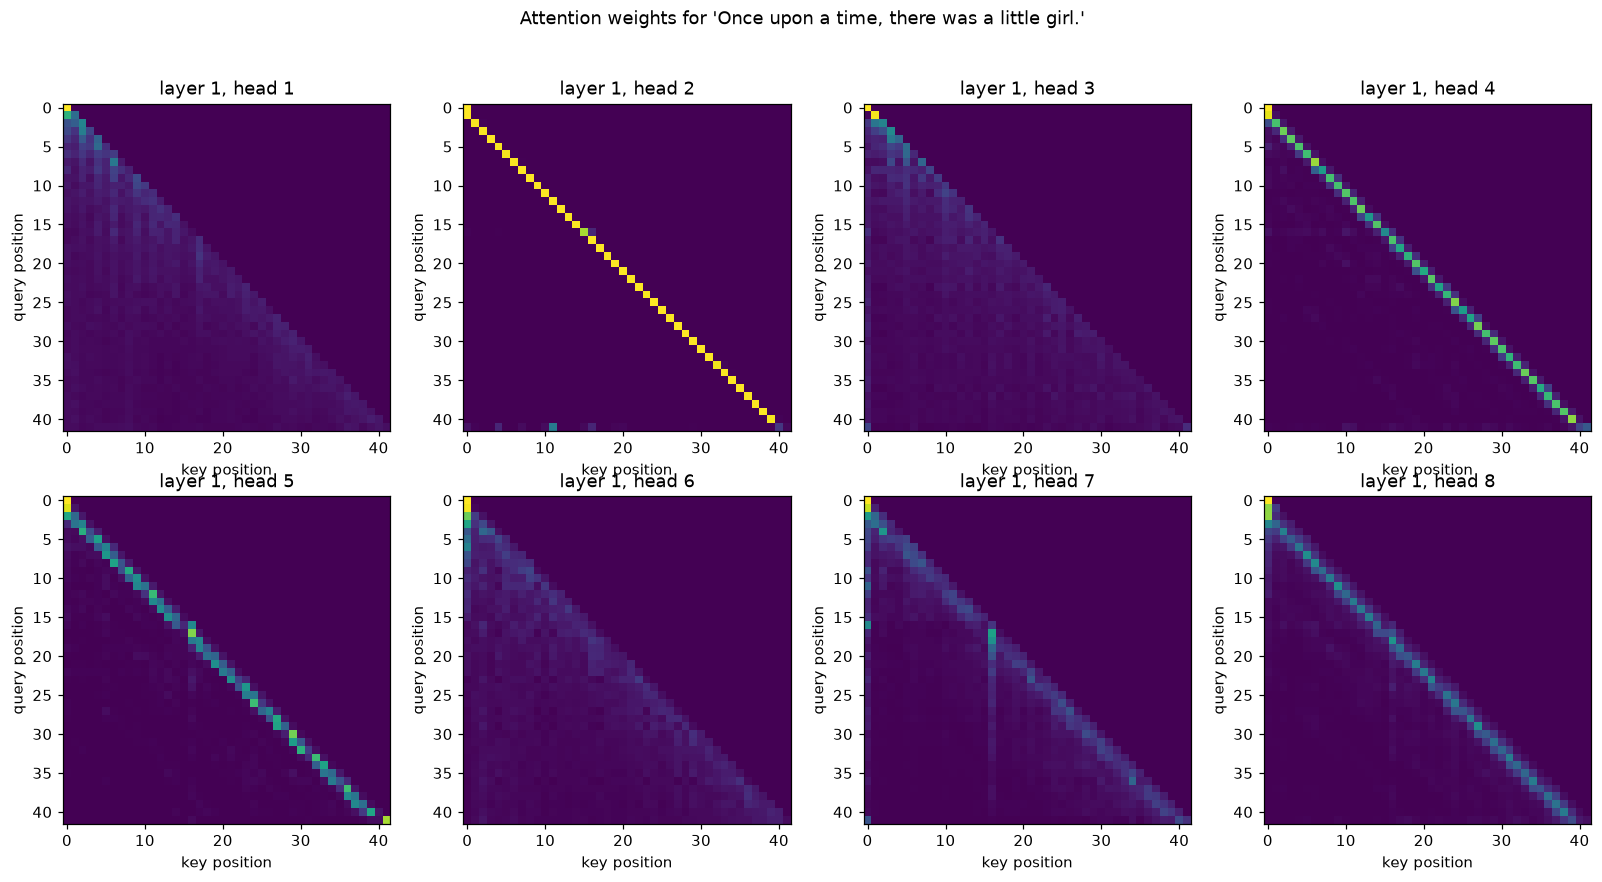

In [50]:
sentence = "Once upon a time, there was a little girl."
ids = torch.tensor([tokenizer.encode(sentence)], device=DEVICE)
with torch.no_grad():
    pos = torch.arange(ids.size(1), device=DEVICE)
    h = model.drop(model.token_embedding(ids) + model.position_embedding(pos))
    _, attn_weights = model.blocks[0].attn(model.blocks[0].ln1(h), return_attn=True)
w = attn_weights[0].float().cpu()
print("total attention weight above the diagonal, all heads:", float(torch.triu(w, diagonal=1).sum()))
n_heads = w.shape[0]
cols = (n_heads + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(4.5 * cols, 8.5), squeeze=False)
for head, ax in zip(range(n_heads), axes.flat):
    ax.imshow(w[head], cmap="viridis")
    ax.set_title(f"layer 1, head {head + 1}")
    ax.set_xlabel("key position")
    ax.set_ylabel("query position")
fig.suptitle(f"Attention weights for {sentence!r}")
show_fig(fig)

### Generated samples

In [51]:
show_table([(i, r["decoding"], r["prompt"], r["seed"], r["new_tokens"], round(r["tokens_per_sec"], 1),
             r["checkpoint_epoch"], r["device"]) for i, r in enumerate(samples, 1)],
           columns=["sample", "decoding", "prompt", "seed", "new chars", "chars/s", "checkpoint epoch", "device"])
for i, r in enumerate(samples, 1):
    print(f"--- sample {i} | {r['decoding']} | seed {r['seed']} ---")
    print(r["text"], "\n")

,sample,decoding,prompt,seed,new chars,chars/s,checkpoint epoch,device
0,1,"temperature=0.8,top_k=50",Once upon a time,8503,500,467.8,10,cuda
1,2,"temperature=0.8,top_k=50",Once upon a time,8504,500,530.9,10,cuda
2,3,"temperature=0.8,top_k=50",Once upon a time,8505,500,524.7,10,cuda
3,4,"temperature=0.8,top_k=50",Tom had a red ball,9503,500,536.0,10,cuda
4,5,"temperature=0.8,top_k=50",Tom had a red ball,9504,500,536.9,10,cuda
5,6,"temperature=0.8,top_k=50",Tom had a red ball,9505,500,520.2,10,cuda
6,7,greedy,Once upon a time,8503,500,575.2,10,cuda


--- sample 1 | temperature=0.8,top_k=50 | seed 8503 ---
Once upon a time, there was a little girl named Mia. She had a big box with a ball in her box. She had a big box that she loved her car. Mia loved to play with her friends. One day, while they were playing, Mia saw a little boy named Tim. Tim was an old turtle boy who was very hot. He wanted to draw a big tree with his boat, so he went to the park and found a vase. He sat down rocks and ran outside with the trees and put it away around the forest? 
The girl was so excited that she couldn't believe her to show h 

--- sample 2 | temperature=0.8,top_k=50 | seed 8504 ---
Once upon a time, there was a little boy named Tim. Tim had a big surprise that he loved very much. Every day, he would not share his room with his toys. One day, Tim went to the park with his mom. They walked to the park together. Tim threw the park and they found a toy to get the park. Tim was happy again.

Once upon a time, there was a small cat named Tom. Tom had

### Comparison with the reported run

When the reported `metrics_report.csv` is present, every metric of this run is listed next to the reported value. Run-specific rows (run id, timings, throughput) are expected to differ. Training on a GPU is not bit-for-bit deterministic, so the losses of a fresh run can differ from the reported ones in the later decimals.

In [52]:
REPORTED_REPORT = MEMBER_DIR / "metrics_report.csv"


def compare_reports(new_report_path, label):
    reported = pd.read_csv(REPORTED_REPORT)
    new = pd.read_csv(new_report_path)
    merged = reported.merge(new, on=["metric", "split_or_setting"], suffixes=(" (reported)", f" ({label})"))

    def abs_diff(row):
        try:
            return abs(float(row[f"value ({label})"]) - float(row["value (reported)"]))
        except (TypeError, ValueError):
            return None

    merged["abs diff"] = merged.apply(abs_diff, axis=1)
    return merged[["metric", "split_or_setting", "value (reported)", f"value ({label})", "abs diff"]]


if REPORTED_REPORT.exists() and not SMOKE:
    display(compare_reports(resolve_path(cfg["paths"]["metrics_report"]), "this notebook"))
else:
    print("Skipped (smoke mode or no reported metrics_report.csv).")

,metric,split_or_setting,value (reported),value (this notebook),abs diff
0,train_cross_entropy,"train (eval mode, subset)",0.720107,0.718891,0.001216
1,train_cross_entropy_epoch_mean,"train (final epoch, dropout on)",0.772148,0.771349,0.000799
2,val_cross_entropy,validation (full),0.739443,0.738079,0.001364
3,perplexity,validation,2.094769,2.091913,0.002856
4,bits_per_character,validation,1.066791,1.064823,0.001968
5,generalization_gap,val - train,0.019336,0.019188,0.000148
6,top1_next_char_accuracy,validation,0.765526,0.766218,0.000692
7,top1_next_char_accuracy,"train (eval mode, subset)",0.770108,0.770704,0.000596
8,distinct_1,"temperature=0.8,top_k=50",0.40591,0.345853,0.060057
9,distinct_2,"temperature=0.8,top_k=50",0.811617,0.721959,0.089658


### Re-evaluating the reported checkpoint (`VERIFY_REPORTED_CHECKPOINT`)

Runs this notebook's generation and evaluation code on the reported `task1_llm/parth/checkpoints/best.pt` and compares the result with the reported metrics and samples. Outputs go to `notebook_runs/<RUN_TAG>/verify_reported/`. The reported training summary is read (not written) from `task1_llm/parth/logs/`, and the evaluation windows are rebuilt from the data split stored in the checkpoint.

In [53]:
REPORTED_BEST = MEMBER_DIR / "checkpoints" / "best.pt"
verify_out = None
if (VERIFY_REPORTED_CHECKPOINT and not SMOKE and REPORTED_BEST.exists() and REPORTED_REPORT.exists()
        and reported_samples_path.exists()):
    VERIFY_DIR = RUN_DIR / "verify_reported"
    VERIFY_REL = repo_relative(VERIFY_DIR)
    verify_cfg = copy.deepcopy(TRAIN_CONFIG)
    verify_cfg["paths"] = {
        "checkpoint_dir": f"{VERIFY_REL}/checkpoints",
        "figures_dir": f"{VERIFY_REL}/figures",
        "logs_dir": "task1_llm/parth/logs",
        "outputs_dir": f"{VERIFY_REL}/outputs",
        "metrics_report": f"{VERIFY_REL}/metrics_report.csv",
        "raw_log_dir": f"{VERIFY_REL}/raw_logs",
        "manifest_dir": f"{VERIFY_REL}/manifests",
    }
    (VERIFY_DIR / "config").mkdir(parents=True, exist_ok=True)
    (VERIFY_DIR / "config" / "train.yaml").write_text(yaml.safe_dump(verify_cfg, sort_keys=False), encoding="utf-8")
    verify_cfg_path = f"{VERIFY_REL}/config/train.yaml"
    verify_txt = f"{VERIFY_REL}/outputs/generated_samples.txt"
    torch.set_float32_matmul_precision("highest")
    for i, gen_argv in enumerate(GENERATION_RUNS):
        generate_main(["--checkpoint", repo_relative(REPORTED_BEST), *gen_argv, "--output", verify_txt]
                      + (["--append"] if i else []))
    verify_out = evaluate_main(["--checkpoint", repo_relative(REPORTED_BEST), "--config", verify_cfg_path,
                                "--samples", verify_txt[: -len(".txt")] + ".jsonl"])
    display(compare_reports(VERIFY_DIR / "metrics_report.csv", "re-evaluated"))
    regen = [json.loads(l) for l in (VERIFY_DIR / "outputs" / "generated_samples.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
    same = sum(a["text"] == b["text"] for a, b in zip(reported_records, regen))
    print(f"{same} of {len(reported_records)} regenerated samples are identical to the reported ones.")
else:
    print("Skipped (flag off, smoke mode, or the reported best.pt / metrics_report.csv is not present).")


--- temperature=0.8,top_k=50 | seed 8503 | 499.5 tok/s ---
Once upon a time, there was a little girl named Mia. She had a big box with a ball and a big, red ball. One day, she saw a big box of wood far on the swings. Mia was very sad.
Lily told Tom to stop and play with him. They were sad because they were not stuck in the pond. They did not know that they were sad and didn't move.
Then he heard a voice and then something unexpected happened. A big cat came and took the park. The cat looked at the zoo and saw the spear was the best of friends and playing together.
The 

--- temperature=0.8,top_k=50 | seed 8504 | 518.0 tok/s ---
Once upon a time, there was a little boy named Tim. Tim had a big purple said, "Hi Tim! You are a nice museum." Tim was very happy, and Tim remembered his mum would have a raven banana.
Tim would be fun to play with his friends and play with his new toy all day. One day, Tim saw a big box of window. It was a big, round tail.
Tim asked, "Why do you like to share

,metric,split_or_setting,value (reported),value (re-evaluated),abs diff
0,train_cross_entropy,"train (eval mode, subset)",0.720107,0.720111,0.000004
1,train_cross_entropy_epoch_mean,"train (final epoch, dropout on)",0.772148,0.772148,0.000000
2,val_cross_entropy,validation (full),0.739443,0.739455,0.000012
3,perplexity,validation,2.094769,2.094794,0.000025
4,bits_per_character,validation,1.066791,1.066808,0.000017
5,generalization_gap,val - train,0.019336,0.019344,0.000008
6,top1_next_char_accuracy,validation,0.765526,0.765467,0.000059
7,top1_next_char_accuracy,"train (eval mode, subset)",0.770108,0.77009,0.000018
8,distinct_1,"temperature=0.8,top_k=50",0.40591,0.40591,0.000000
9,distinct_2,"temperature=0.8,top_k=50",0.811617,0.811617,0.000000


7 of 7 regenerated samples are identical to the reported ones.


## 14. Failure analysis

Three failure cases, each with a generated snippet, a failure type (for example repetition, broken grammar, loss of coherence, hallucination) and an observation. The candidates are the samples printed in section 13, and the table below gives per-sample statistics. If this run's samples differ from the reported ones (comparison in section 13), the cases quote the reported run, whose seven samples are reproduced in `failure_analysis.md`.

In [54]:
per_sample = []
for i, r in enumerate(samples, 1):
    words = r["continuation"].split()
    per_sample.append({
        "sample": i,
        "decoding": r["decoding"],
        "seed": r["seed"],
        "words in continuation": len(words),
        "distinct-1": distinct_n([words], 1),
        "distinct-2": distinct_n([words], 2),
        "repeated 4-gram rate": repeated_ngram_rate([words], 4),
    })
display(pd.DataFrame(per_sample).round(4))

,sample,decoding,seed,words in continuation,distinct-1,distinct-2,repeated 4-gram rate
0,1,"temperature=0.8,top_k=50",8503,109,0.6606,0.9352,0.0189
1,2,"temperature=0.8,top_k=50",8504,107,0.6449,0.9057,0.0000
2,3,"temperature=0.8,top_k=50",8505,106,0.6415,0.9143,0.0097
3,4,"temperature=0.8,top_k=50",9503,101,0.6139,0.8900,0.0000
4,5,"temperature=0.8,top_k=50",9504,108,0.6574,0.9159,0.0000
5,6,"temperature=0.8,top_k=50",9505,108,0.6481,0.9439,0.0000
6,7,greedy,8503,111,0.5135,0.7636,0.0833


### Failure case 1

- **Sample:** reported-run candidate 1 in `failure_analysis.md` (temperature 0.8, top-k 50, seed 8503, prompt "Once upon a time")
- **Generated snippet:** `there was a little girl named Mia. [...] Mia was very sad. Lily told Tom to stop and play with him.`
- **Failure type:** Entity and name inconsistency (loss of coherence)
- **Observation:** The sample introduces Mia as the main character and mentions her again, then continues with Lily and Tom as if they had already appeared. Mia's second mention starts at character 158 and "Lily" appears at character 176, so Mia was still inside the 128-character window and the switch is not explained by the context limit alone. Each sentence is locally grammatical, but the story does not keep track of who it is about.

### Failure case 2

- **Sample:** reported-run candidate 2 in `failure_analysis.md` (temperature 0.8, top-k 50, seed 8504, prompt "Once upon a time")
- **Generated snippet:** `Tim had a big purple said, "Hi Tim! You are a nice museum." [...] his mum would have a raven banana. [...] Tim saw a big box of window. It was a big, round tail.`
- **Failure type:** Semantic incoherence and broken grammar
- **Observation:** The words are spelled correctly and are common in TinyStories, but they are combined without meaning. "A big purple said" drops the noun the adjectives need, and "a nice museum", "a raven banana" and "a big box of window" join words that do not fit the sentence or each other. The model has learned word forms and short-range word order, but not which words make sense together.

### Failure case 3

- **Sample:** reported-run candidate 7 in `failure_analysis.md` (greedy decoding, seed 8503, prompt "Once upon a time")
- **Generated snippet:** `He wanted to play with it. Tim thought it would be fun to play with it. [...] He wanted to play with it. He took the box and started to play with it. [...] "I want to play with you, but I want to play with you."`
- **Failure type:** Repetition under greedy decoding
- **Observation:** "to play with it" appears four times in 500 characters, "He wanted to play with it." repeats as a whole sentence, and one line of dialogue repeats its own first clause. The sample's repeated 4-gram rate is 0.073, against 0.000 for the six temperature samples. Greedy decoding always takes the single most likely next character, so a likely phrase tends to recur; temperature sampling with top-k breaks these loops but produces more incoherent combinations, as in candidate 2.

### Summary across the cases

The three cases fail in different ways: entity drift (case 1), meaningless word combinations (case 2) and repetition under greedy decoding (case 3). Spelling is mostly correct in all of them, so the errors are in meaning, entity tracking and repetition rather than in characters, which fits metrics (top-1 accuracy 0.766, perplexity 2.09) that reward local next-character prediction.

Possible causes, none of them tested here, are the 128-character context (about 28 words), the small model (3.2M parameters, 10 epochs) and the decoding settings. Case 1 shows the context limit is not the whole explanation, because the name changed while the original name was still in the window. The greedy sample's repeated 4-gram rate (0.073, against 0.000 for the six temperature samples) points to decoding as one factor in case 3; `failure_analysis.md` lists all seven samples and proposed tests.

## 15. Architecture and hyperparameter justification

The table lists the choices discussed below, read from this run's config and training summary.

In [55]:
m = cfg["model"]
show_table([
    ("architecture", f"{m['model_type']}, {m['normalization']}"),
    ("positional embedding", m["positional_embedding"]),
    ("FFN activation / hidden size",
     f"{m['activation']}, {m['ffn_hidden_multiplier']} x d_model = {m['ffn_hidden_multiplier'] * m['d_model']}"),
    ("weight tying (embedding / output)", m["tie_weights"]),
    ("d_model / heads / head size", f"{m['d_model']} / {m['n_heads']} / {m['d_model'] // m['n_heads']}"),
    ("layers", m["n_layers"]),
    ("context length (characters)", m["context_length"]),
    ("dropout", m["dropout"]),
    ("parameters", f"{summary['parameter_count']:,}"),
    ("peak LR / warm-up / final LR ratio", f"{tcfg['learning_rate']} / {tcfg['warmup_ratio']:.0%} / {tcfg['min_lr_ratio']}"),
    ("batch size / epochs", f"{tcfg['batch_size']} / {tcfg['epochs']}"),
    ("weight decay / betas / clipping", f"{tcfg['weight_decay']} / {tuple(tcfg['betas'])} / {tcfg['grad_clip']}"),
    ("split", f"{cfg['data']['split_unit']}: {cfg['data']['train_size']:,} train / {cfg['data']['val_size']:,} val, "
              f"whole stories, seed {SEED}"),
], columns=["choice", "value"])

,choice,value
0,architecture,"decoder-only-gpt, pre-norm"
1,positional embedding,learned
2,FFN activation / hidden size,"gelu, 4 x d_model = 1024"
3,weight tying (embedding / output),False
4,d_model / heads / head size,256 / 8 / 32
5,layers,4
6,context length (characters),128
7,dropout,0.1
8,parameters,"3,233,792"
9,peak LR / warm-up / final LR ratio,0.0003 / 5% / 0.1


Reported-run numbers (from `results.md`): 3,233,792 parameters; 10 epochs in 92 s on one RTX 5090; validation cross-entropy 0.7394 nats/char (perplexity 2.09, 1.07 bits per character); generalization gap 0.019; final-epoch mean training loss 0.7721.

### 1. Split unit

**Split unit.** The handout gives the split sizes (100K / 10K) without a unit. This run counts fixed-length sequences (`split_unit: sequences`): 100,000 training and 10,000 validation windows of 128 characters, since one window is one input-target training example. `split_unit` only decides what `train_size` and `val_size` count; it does not change how stories are separated.

**Why whole stories are split before windows are cut.** `split_stories` shuffles the loaded stories with the seed, assigns whole stories to validation first, and then assigns the following stories to training, until each side has enough characters for its window count. Only after that are the two text streams tokenized and cut into windows, so every story's characters land in exactly one split and no window can contain text from both. If windows from one story appeared on both sides, the validation loss would partly measure recall of names and phrases already seen in training and would overstate how well the model handles unseen stories.

### 2. Split procedure

**Split procedure.** The handout asks each member to create their own split; this one is produced from the raw TinyStories file by the project's `split_stories` function and a `CharTokenizer` fit on the training text only. It is deterministic: the first 80,000 stories in file order are shuffled with `random.Random(8503)`, so the same file and seed always give the same split. The reported split uses 1,610 validation stories (1,280,350 characters) and 15,880 training stories (12,800,004 characters); the other 62,510 loaded stories are not used.

### 3. Architecture choices

**Character-level modelling.** The vocabulary is 81 symbols (80 characters seen in the training text plus an unknown id), so the token embedding and the LM head together hold only 41,472 of the 3,233,792 parameters. No word can be out of vocabulary, because any word is spelled from known characters; the validation text contained 0 unknown characters. The cost is sequence length: the generated text averages about 4.6 characters per word including the space, so a 128-character window holds roughly 28 words, and spelling, word boundaries and sentence structure all have to be learned from single characters.

**Hand-written causal self-attention** (`scaled_dot_product_attention` and `MultiHeadSelfAttention` in `src/model.py`):

- One fused `Linear(256, 768)` produces a query, key and value vector for every position. The result is split into Q, K and V and reshaped to (B, 8, T, 32), one slice per head.
- Scores are `Q K^T / sqrt(32)`, computed with `torch.matmul`; entry (t, s) measures how well query t matches key s. Dividing by the square root of the head dimension keeps the variance of the scores near 1, so the softmax does not saturate into near one-hot weights.
- The causal mask is a lower-triangular boolean matrix (`torch.tril`). Scores where key s comes after query t are set to `-inf`, so their weights after the softmax are exactly 0. Without the mask, position t could read the character it is being trained to predict, the training loss would be trivially low, and the model would fail at generation, where future characters do not exist yet.
- The softmax turns each row of scores into weights that sum to 1, and each position's output is the weighted sum of the value vectors of the positions it is allowed to see.
- The softmax is computed in float32 (`torch.softmax(scores.float(), dim=-1)`) and cast back, even under bf16 autocast. Exponentiation is where low-precision attention first overflows or loses precision, and running this one step in float32 is cheap.

**Multi-head attention.** The 256-dimensional vector is split into 8 heads of 32 dimensions, each with its own slice of Q, K and V and its own attention pattern, so different heads can attend to different earlier positions at the same time. The heads are concatenated back to 256 dimensions and mixed by `out_proj`, so 8 heads use the same projection parameters as a single 256-dimensional head.

**Pre-norm.** Each block computes `x = x + attn(ln1(x))` and then `x = x + ffn(ln2(x))`: LayerNorm normalizes the input of each sublayer, while the residual stream itself is never normalized. That leaves a direct identity path from the embeddings to the final LayerNorm, which keeps gradients well scaled through the stack and is generally more stable early in training than post-norm. This run had zero non-finite steps and zero loss spikes; no post-norm model was trained for comparison.

**Learned positional embeddings.** Attention on its own compares positions only by content: without the mask it is permutation-equivariant, and with the causal mask it knows which positions are earlier but not how far back they are. A learned 128 x 256 position table added to the token embeddings gives every position its own vector, which is simple for a fixed maximum length of 128 and costs 32,768 parameters. Sinusoidal encodings would also have worked; they were not compared.

**GELU.** The FFN uses GELU, x multiplied by the standard normal CDF of x. It is a smooth version of ReLU that keeps a small nonzero gradient for slightly negative inputs, and it is the standard activation in GPT-style models such as GPT-2; ReLU was not compared.

**No weight tying.** The LM head is its own 256 x 81 matrix (`tie_weights: false`). With an 81-symbol vocabulary, tying would save only 20,736 parameters (0.64% of the model), while separate matrices let the input embedding and the output projection learn different representations. The code supports tying, but no tied model was trained.

### 4. Model size

Parameter count by component, computed from the layer shapes (the sum matches the logged count):

| Component | Parameters | Share |
|---|---|---|
| Feed-forward networks (4 x 525,568) | 2,102,272 | 65.0% |
| Attention projections, QKV and output (4 x 263,168) | 1,052,672 | 32.6% |
| Position embedding (128 x 256) | 32,768 | 1.0% |
| Token embedding (81 x 256) | 20,736 | 0.6% |
| LM head (256 x 81) | 20,736 | 0.6% |
| LayerNorms (9 x 512) | 4,608 | 0.1% |
| **Total** | **3,233,792** | |

The FFN is about two thirds of every block because it expands each position from 256 to 1,024 units and back: two 256 x 1,024 matrices (524,288 weights), against attention's 256 x 768 QKV and 256 x 256 output matrices (262,144 weights). The embeddings and LM head are under 3% of the total because the vocabulary has only 81 symbols.

At this size one 10-epoch run took 92 s on the RTX 5090 with 1.24 GB of peak GPU memory, and the model saw 127,959,040 training characters, about 40 per parameter. These dimensions were chosen as a small configuration for the lab, not tuned; no other model size was trained.

### 5. Training hyperparameters

| Setting | Value | Purpose |
|---|---|---|
| Optimizer | AdamW, betas (0.9, 0.95) | Per-parameter adaptive steps with decoupled weight decay. A beta2 of 0.95 lets the second-moment estimate follow changes in gradient scale faster than the default 0.999, a common setting for Transformer training. |
| Weight decay | 0.01, 2-D weights only | Light regularization of the weight matrices. Biases and LayerNorm gains are excluded because pulling them toward zero does not regularize the model. |
| Peak learning rate | 3e-4 | The largest step size, reached at the end of warmup. |
| Warmup | Linear over 390 steps (5% of 7,810) | Keeps early updates small while the weights are random and Adam's moment estimates are still noisy. The raw log shows 1.538e-06 at step 1 and 3.000e-04 at step 400. |
| Decay | Cosine to 3e-5 (10% of peak) | Lowers the step size smoothly so late training makes smaller, finer updates; 3.000e-05 at step 7,800. |
| Batch size | 128 windows (16,384 characters) | 781 optimizer steps per epoch and 7,810 in total, at 1.24 GB of peak GPU memory. |
| Epochs | 10 | The lab minimum. |
| Dropout | 0.1 | Light regularization on the embeddings, attention weights and residual branches. |
| Gradient clipping | Global L2 norm 1.0 | Caps the size of any single update. The pre-clip norm averaged 0.77 with a maximum of 9.55, and 13.3% of steps were clipped. |
| Mixed precision | bf16 autocast | Less memory and faster matrix multiplies than fp32. bf16 keeps fp32's 8-bit exponent, so unlike fp16 it does not overflow at large values and needs no loss scaling; no GradScaler is used on this GPU. |
| Seed | 8503 | Seeds Python, NumPy and PyTorch, which fixes the story shuffle, the weight initialization and the batch order. |

**Alternatives.** The preserved evidence contains only this configuration, plus a reduced smoke run (d_model 64, 2 layers, context 64) used to test the pipeline. No alternative hyperparameter run is claimed.

### 6. Loss curves

Both losses fall in every epoch: the epoch-mean training loss from 2.0034 to 0.7721, and the validation loss from 1.2159 to 0.7394. The validation loss never turns upward, but its per-epoch improvement shrinks from 0.2572 (epoch 1 to 2) to 0.0039 (epoch 9 to 10), so the curve is flattening while still improving at epoch 10. More epochs might have lowered it further; that was not tested.

There is no sign of overfitting. Measured the same way, in eval mode, the training cross-entropy is 0.7201 and the validation cross-entropy is 0.7394, a gap of 0.019 nats per character.

The epoch-mean training loss (0.7721) sits above the validation loss for two reasons. It is computed with dropout on, so each step's loss comes from a randomly thinned network, and it averages every step of the epoch, including steps taken before the weights reached their end-of-epoch values. The validation loss is measured once, after the epoch, with dropout off, so the eval-mode training cross-entropy (0.7201) is the like-for-like comparison.

### 7. Metrics

- **Cross-entropy** is the average negative log-probability, in nats, that the model assigns to the true next character, over every position of every validation window. Validation: 0.739443.
- **Perplexity** = exp(cross-entropy) = 2.094769. On average the model is about as uncertain as a uniform choice among 2.1 characters, against 81 for a uniform guess over the vocabulary. It is a per-character number, so it cannot be compared with the perplexity of a word- or subword-level GPT, where each token is a much larger unit.
- **Bits per character** = cross-entropy / ln 2 = 1.066791. It is the same quantity in bits: roughly one bit of information per character of validation text.
- **Top-1 accuracy** = 0.765526. The single most likely next character is correct at 76.6% of validation positions (0.770108 on the training subset).
- **Generalization gap** = 0.019336 nats per character (validation minus training, both in eval mode). It is small, which matches the loss curves.
- **Diversity.** Distinct-2/3 are higher for the six temperature samples (0.812 / 0.933) than for the greedy sample (0.757 / 0.845), and the repeated 4-gram rate is 0.000 against 0.073. Distinct-1 is higher for greedy (0.527 against 0.406), but distinct-n is pooled over all samples of a setting, and pooling six stories that share a vocabulary lowers the unique-word ratio, so distinct-1 does not compare 6 samples with 1 fairly. With a single greedy sample this is an observation, not a statistically reliable difference.

### 8. Limitations

- **Short context.** The model sees at most 128 characters, about 28 words, so anything earlier in a story is invisible when the next character is predicted.
- **Small model and short training.** 3.2M parameters trained for 10 epochs (92 s), and the validation loss was still falling at epoch 10.
- **Character-level learning.** Words and their meanings have to be built up from single characters, and the samples contain correctly spelled words in combinations that make no sense (`failure_analysis.md`, candidate 2).
- **Generated-text failures.** The samples show name and entity drift, pronoun errors, story restarts and repetition under greedy decoding (`failure_analysis.md`).
- **Evaluation scope.** One seed and one run, diversity from only 7 samples (1 greedy), and validation on held-out stories from the same TinyStories file, so there is no measure of run-to-run variation or of out-of-distribution text.
- **Next steps.** Train with a longer context and for more epochs while the validation loss still improves, repeat with several seeds, and measure diversity and failure counts over many more samples.

## 16. Summary

In [56]:
show_table([
    ("run id", summary["run_id"]),
    ("run folder", RUN_REL),
    ("hardware", summary["hardware"]),
    ("parameters", f"{summary['parameter_count']:,}"),
    ("train / val windows", f"{split['train_windows']:,} / {split['val_windows']:,} x {split['context_length']} characters"),
    ("vocabulary size", split["vocab_size"]),
    ("epochs (best epoch)", f"{summary['epochs_completed']} ({summary['best_epoch']})"),
    ("validation cross-entropy (nats/char)", metric(report, "val_cross_entropy")),
    ("perplexity", metric(report, "perplexity")),
    ("bits per character", metric(report, "bits_per_character")),
    ("generalization gap", metric(report, "generalization_gap")),
    ("top-1 next-character accuracy (validation)", metric(report, "top1_next_char_accuracy", "validation")),
    ("total training time (s)", round(summary["total_training_time_sec"], 2)),
    ("non-finite / loss-spike steps",
     f"{summary['nan_loss_steps'] + summary['nonfinite_grad_steps']} / {summary['loss_spike_steps']}"),
], columns=["item", "value"])

,item,value
0,run id,parth_gpt_char_v1_20261002T220241Z
1,run folder,task1_llm/parth/notebook_runs/gpu_run
2,hardware,NVIDIA GeForce RTX 5090
3,parameters,"3,233,792"
4,train / val windows,"100,000 / 10,000 x 128 characters"
5,vocabulary size,81
6,epochs (best epoch),10 (10)
7,validation cross-entropy (nats/char),0.738079
8,perplexity,2.091913
9,bits per character,1.064823


- Sections 4 to 11 contain the complete implementation: data loading and split, tokenizer, windowed dataset, Transformer, training loop, evaluation, and generation.
- Section 12 runs the experiment; sections 13 and 16 show its results from the files in the run folder, including the raw log and manifest.